# CHAPTER 14 : Data Analysis Examples
<hr class="reddot">

In [6]:
%run "Ch00 - Basic Imports and Set ups.ipynb"

In [7]:
import seaborn as sns
from collections import defaultdict 
from collections import Counter
import json
import pandas as pd
import matplotlib.pyplot as plt

Now that we’ve reached the end of this book’s main chapters, we’re going to take a
look at a number of real-world datasets. For each dataset, we’ll use the techniques
presented in this book to extract meaning from the raw data. The demonstrated techniques
can be applied to all manner of other datasets, including your own. This chapter
contains a collection of miscellaneous example datasets that you can use for
practice with the tools in this book.
The example datasets are found in the book’s accompanying GitHub repository.

## 14.1 USA.gov Data from Bitly

In 2011, URL shortening service Bitly partnered with the US government website
USA.gov to provide a feed of anonymous data gathered from users who shorten links
ending with .gov or .mil. In 2011, a live feed as well as hourly snapshots were available
as downloadable text files. This service is shut down at the time of this writing (2017),
but we preserved one of the data files for the book’s examples.
In the case of the hourly snapshots, each line in each file contains a common form of
web data known as JSON, which stands for JavaScript Object Notation. For example,
if we read just the first line of a file we may see something like this:

In [8]:
path = 'examples/example.txt'

In [9]:
open(path).readline()

'{ "a": "Mozilla\\/5.0 (Windows NT 6.1; WOW64) AppleWebKit\\/535.11 (KHTML, like Gecko) Chrome\\/17.0.963.78 Safari\\/535.11", "c": "US", "nk": 1, "tz": "America\\/New_York", "gr": "MA", "g": "A6qOVH", "h": "wfLQtf", "l": "orofrog", "al": "en-US,en;q=0.8", "hh": "1.usa.gov", "r": "http:\\/\\/www.facebook.com\\/l\\/7AQEFzjSi\\/1.usa.gov\\/wfLQtf", "u": "http:\\/\\/www.ncbi.nlm.nih.gov\\/pubmed\\/22415991", "t": 1331923247, "hc": 1331822918, "cy": "Danvers", "ll": [ 42.576698, -70.954903 ] }\n'

Python has both built-in and third-party libraries for converting a JSON string into a
Python dictionary object. Here we’ll use the `json` module and its `loads` function
invoked on each line in the sample file we downloaded:

In [10]:
import json
path = 'examples/example.txt'
records = [json.loads(line) for line in open(path)]

The resulting object `records` is now a list of Python dicts:

In [11]:
records[0]

{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
 'c': 'US',
 'nk': 1,
 'tz': 'America/New_York',
 'gr': 'MA',
 'g': 'A6qOVH',
 'h': 'wfLQtf',
 'l': 'orofrog',
 'al': 'en-US,en;q=0.8',
 'hh': '1.usa.gov',
 'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
 'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
 't': 1331923247,
 'hc': 1331822918,
 'cy': 'Danvers',
 'll': [42.576698, -70.954903]}

In [12]:
records[0:2]

[{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
  'c': 'US',
  'nk': 1,
  'tz': 'America/New_York',
  'gr': 'MA',
  'g': 'A6qOVH',
  'h': 'wfLQtf',
  'l': 'orofrog',
  'al': 'en-US,en;q=0.8',
  'hh': '1.usa.gov',
  'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
  'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
  't': 1331923247,
  'hc': 1331822918,
  'cy': 'Danvers',
  'll': [42.576698, -70.954903]},
 {'a': 'GoogleMaps/RochesterNY',
  'c': 'US',
  'nk': 0,
  'tz': 'America/Denver',
  'gr': 'UT',
  'g': 'mwszkS',
  'h': 'mwszkS',
  'l': 'bitly',
  'hh': 'j.mp',
  'r': 'http://www.AwareMap.com/',
  'u': 'http://www.monroecounty.gov/etc/911/rss.php',
  't': 1331923249,
  'hc': 1308262393,
  'cy': 'Provo',
  'll': [40.218102, -111.613297]}]

### Counting Time Zones in Pure Python

Suppose we were interested in finding the most often-occurring time zones in the
dataset (the tz field). There are many ways we could do this. First, let’s extract a list of
time zones again using a list comprehension:

In [13]:
time_zones = [rec['tz'] for rec in records]

KeyError: 'tz'

Oops! Turns out that not all of the records have a time zone field. This is easy to handle,
as we can add the check if `'tz' in rec at the end of the list comprehension:

In [14]:
time_zones = [rec['tz'] for rec in records if 'tz' in rec]

In [15]:
time_zones[:10]

['America/New_York',
 'America/Denver',
 'America/New_York',
 'America/Sao_Paulo',
 'America/New_York',
 'America/New_York',
 'Europe/Warsaw',
 '',
 '',
 '']

Just looking at the first 10 time zones, we see that some of them are unknown (empty
string). You can filter these out also, but I’ll leave them in for now. Now, to produce
counts by time zone I’ll show two approaches: the harder way (using just the Python
standard library) and the easier way (using pandas). One way to do the counting is to
use a dict to store counts while we iterate through the time zones:

In [16]:
def get_counts(sequence):
    counts = {}
    for x in sequence:
        if x in counts:
            counts[x] += 1
        else:
            counts[x] = 1
    return counts

In [17]:
counts = get_counts(time_zones)

In [18]:
list(counts.items())[:5]

[('America/New_York', 1251),
 ('America/Denver', 191),
 ('America/Sao_Paulo', 33),
 ('Europe/Warsaw', 16),
 ('', 521)]

Using more advanced tools in the Python standard library, you can write the same
thing more briefly:

In [19]:
from collections import defaultdict

In [20]:
def get_counts2(sequence):
    counts = defaultdict(int) # values will initialize to 0
    for x in sequence:
        counts[x] += 1
    return counts

In [21]:
counts2 = get_counts2(time_zones)

In [22]:
list(counts2.items())[:5]

[('America/New_York', 1251),
 ('America/Denver', 191),
 ('America/Sao_Paulo', 33),
 ('Europe/Warsaw', 16),
 ('', 521)]

If we wanted the top 10 time zones and their counts, we can do a bit of dictionary
acrobatics:

In [23]:
def top_counts(count_dict, n=10):
    value_key_pairs = [(count, tz) for tz, count in count_dict.items()]
    value_key_pairs.sort()
    return value_key_pairs[-n:]

In [24]:
top_counts(counts)

[(33, 'America/Sao_Paulo'),
 (35, 'Europe/Madrid'),
 (36, 'Pacific/Honolulu'),
 (37, 'Asia/Tokyo'),
 (74, 'Europe/London'),
 (191, 'America/Denver'),
 (382, 'America/Los_Angeles'),
 (400, 'America/Chicago'),
 (521, ''),
 (1251, 'America/New_York')]

If you search the Python standard library, you may find the `collections.Counter`
class, which makes this task a lot easier:

In [25]:
from collections import Counter

In [26]:
counts = Counter(time_zones)

In [27]:
counts.most_common(10)

[('America/New_York', 1251),
 ('', 521),
 ('America/Chicago', 400),
 ('America/Los_Angeles', 382),
 ('America/Denver', 191),
 ('Europe/London', 74),
 ('Asia/Tokyo', 37),
 ('Pacific/Honolulu', 36),
 ('Europe/Madrid', 35),
 ('America/Sao_Paulo', 33)]

### Counting Time Zones with pandas

Creating a DataFrame from the original set of records is as easy as passing the list of
records to `pandas.DataFrame`:

In [28]:
import pandas as pd

In [29]:
frame = pd.DataFrame(records)

In [30]:
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   object 
 1   c            2919 non-null   object 
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   object 
 4   gr           2919 non-null   object 
 5   g            3440 non-null   object 
 6   h            3440 non-null   object 
 7   l            3440 non-null   object 
 8   al           3094 non-null   object 
 9   hh           3440 non-null   object 
 10  r            3440 non-null   object 
 11  u            3440 non-null   object 
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   object 
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     object 
dtypes: float64(4), object(14)
memory usage: 500.8+ K

In [31]:
frame['tz'][:10]

0     America/New_York
1       America/Denver
2     America/New_York
3    America/Sao_Paulo
4     America/New_York
5     America/New_York
6        Europe/Warsaw
7                     
8                     
9                     
Name: tz, dtype: object

The output shown for the frame is the summary view, shown for large DataFrame
objects. We can then use the `value_counts` method for Series:

In [32]:
tz_counts = frame['tz'].value_counts()

In [33]:
tz_counts[:10]

tz
America/New_York       1251
                        521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Europe/London            74
Asia/Tokyo               37
Pacific/Honolulu         36
Europe/Madrid            35
America/Sao_Paulo        33
Name: count, dtype: int64

We can visualize this data using matplotlib. You can do a bit of munging to fill in a
substitute value for unknown and missing time zone data in the records. We replace
the missing values with the `fillna` method and use boolean array indexing for the
empty strings:

In [34]:
clean_tz = frame['tz'].fillna('Missing')

In [35]:
clean_tz[clean_tz == ''] = 'Unknown'

In [36]:
tz_counts = clean_tz.value_counts()

In [37]:
tz_counts[:10]

tz
America/New_York       1251
Unknown                 521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Missing                 120
Europe/London            74
Asia/Tokyo               37
Pacific/Honolulu         36
Europe/Madrid            35
Name: count, dtype: int64

At this point, we can use the seaborn package to make a horizontal bar plot

In [38]:
import seaborn as sns

In [39]:
subset = tz_counts[:10]

<Axes: ylabel='tz'>

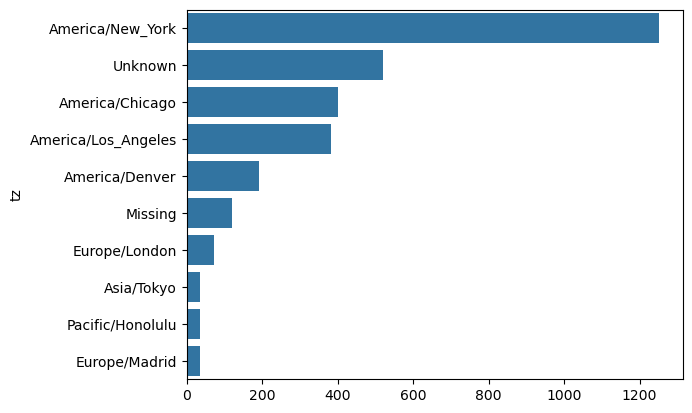

In [40]:
sns.barplot(y=subset.index, x=subset.values)

The a field contains information about the browser, device, or application used to
perform the URL shortening:

In [41]:
frame['a'][1]

'GoogleMaps/RochesterNY'

In [42]:
frame['a'][50]

'Mozilla/5.0 (Windows NT 5.1; rv:10.0.2) Gecko/20100101 Firefox/10.0.2'

In [43]:
frame['a'][51][:50]

'Mozilla/5.0 (Linux; U; Android 2.2.2; en-us; LG-P9'

Parsing all of the interesting information in these “agent” strings may seem like a
daunting task. One possible strategy is to split off the first token in the string (corresponding
roughly to the browser capability) and make another summary of the user
behavior:

In [44]:
results = pd.Series([x.split()[0] for x in frame.a.dropna()])

In [45]:
results[:5]

0               Mozilla/5.0
1    GoogleMaps/RochesterNY
2               Mozilla/4.0
3               Mozilla/5.0
4               Mozilla/5.0
dtype: object

In [46]:
results.value_counts()[:8]

Mozilla/5.0                 2594
Mozilla/4.0                  601
GoogleMaps/RochesterNY       121
Opera/9.80                    34
TEST_INTERNET_AGENT           24
GoogleProducer                21
Mozilla/6.0                    5
BlackBerry8520/5.0.0.681       4
Name: count, dtype: int64

Now, suppose you wanted to decompose the top time zones into Windows and non-
Windows users. As a simplification, let’s say that a user is on Windows if the string
`'Windows'` is in the agent string. Since some of the agents are missing, we’ll exclude
these from the data:

In [47]:
cframe = frame[frame.a.notnull()]

In [48]:
cframe['os'] = np.where(cframe['a'].str.contains('Windows'),
                        'Windows', 'Not Windows')

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\3797563346.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cframe['os'] = np.where(cframe['a'].str.contains('Windows'),


In [49]:
cframe.loc[:, 'os'] = np.where(
    cframe['a'].str.contains('Windows'),
    'Windows',
    'Not Windows'
)

In [50]:
cframe.head()

,a,c,nk,tz,gr,g,h,l,al,hh,r,u,t,hc,cy,ll,_heartbeat_,kw,os
0,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,1.0,America/New_York,MA,A6qOVH,wfLQtf,orofrog,"en-US,en;q=0.8",1.usa.gov,http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/...,http://www.ncbi.nlm.nih.gov/pubmed/22415991,1.331923e+09,1.331823e+09,Danvers,"[42.576698, -70.954903]",NaN,NaN,Windows
1,GoogleMaps/RochesterNY,US,0.0,America/Denver,UT,mwszkS,mwszkS,bitly,NaN,j.mp,http://www.AwareMap.com/,http://www.monroecounty.gov/etc/911/rss.php,1.331923e+09,1.308262e+09,Provo,"[40.218102, -111.613297]",NaN,NaN,Not Windows
2,Mozilla/4.0 (compatible; MSIE 8.0; Windows NT ...,US,1.0,America/New_York,DC,xxr3Qb,xxr3Qb,bitly,en-US,1.usa.gov,http://t.co/03elZC4Q,http://boxer.senate.gov/en/press/releases/0316...,1.331923e+09,1.331920e+09,Washington,"[38.9007, -77.043098]",NaN,NaN,Windows
3,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_6_8)...,BR,0.0,America/Sao_Paulo,27,zCaLwp,zUtuOu,alelex88,pt-br,1.usa.gov,direct,http://apod.nasa.gov/apod/ap120312.html,1.331923e+09,1.331923e+09,Braz,"[-23.549999, -46.616699]",NaN,NaN,Not Windows
4,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,0.0,America/New_York,MA,9b6kNl,9b6kNl,bitly,"en-US,en;q=0.8",bit.ly,http://www.shrewsbury-ma.gov/selco/,http://www.shrewsbury-ma.gov/egov/gallery/1341...,1.331923e+09,1.273672e+09,Shrewsbury,"[42.286499, -71.714699]",NaN,NaN,Windows


In [51]:
cframe['os'][:5]

0        Windows
1    Not Windows
2        Windows
3    Not Windows
4        Windows
Name: os, dtype: object

<details class="collapsible blue-box">
<summary>📘 Click to expand explanation for the warning</summary>

##### Why this warning happens (very important concept)

This warning is one of the **most important pandas gotchas**.

When you do something like:

```python
cframe = frame[frame['something'] > 0]
```

`cframe` may be:

* a **view** (points to original data), OR
* a **copy** (independent data)

👉 Pandas **does not guarantee which one**.

So when you run:

```python
cframe['os'] = ...
```

pandas is basically saying:

> “I’m not sure if you’re modifying the original DataFrame or just a temporary slice.”

That’s why you see:

```
SettingWithCopyWarning
```

---

##### Correct (and safe) way to fix it

Use `.loc` explicitly:

```python
cframe.loc[:, 'os'] = np.where(
    cframe['a'].str.contains('Windows'),
    'Windows',
    'Not Windows'
)
```

✔ This tells pandas clearly:

* “Modify all rows (`:`)”
* “Set column `os`”

---

##### Even better (architect-level clean approach)

If `cframe` was created as a slice → make it explicit:

```python
cframe = cframe.copy()

cframe['os'] = np.where(
    cframe['a'].str.contains('Windows'),
    'Windows',
    'Not Windows'
)
```

✔ This removes ambiguity completely
✔ No warning
✔ Safer for production pipelines

---

##### Why this matters in real systems

In data pipelines (ETL, ML preprocessing):

* Silent bugs can happen if you think you're modifying data but you're not
* Or worse → you accidentally modify the original dataset

This warning is pandas trying to **protect you from non-deterministic behavior**

---

##### Mental model (remember this)

Think of pandas slicing like:

> “Sometimes copy, sometimes reference — assume danger unless explicit”

---

##### Best practices checklist

Always follow these rules:

1. **After filtering → use `.copy()`**

   ```python
   df2 = df[df['x'] > 0].copy()
   ```

2. **When assigning → use `.loc`**

   ```python
   df.loc[:, 'col'] = value
   ```

3. **Avoid chained indexing**

   ```python
   df[df['x'] > 0]['y'] = 1   ❌ BAD
   ```

---

##### Your fixed version (final clean code)

```python
cframe = cframe.copy()

cframe.loc[:, 'os'] = np.where(
    cframe['a'].str.contains('Windows'),
    'Windows',
    'Not Windows'
)
```

---

If you want, I can also show:

* how this bug actually corrupts ML pipelines (very common in feature engineering)
* or how to detect chained indexing issues systematically in large codebases


Then, you can group the data by its time zone column and this new list of operating
systems:

In [52]:
by_tz_os = cframe.groupby(['tz', 'os'])

In [53]:
by_tz_os.size()

tz                 os         
                   Not Windows    245
                   Windows        276
Africa/Cairo       Windows          3
Africa/Casablanca  Windows          1
Africa/Ceuta       Windows          2
                                 ... 
Europe/Warsaw      Windows         15
Europe/Zurich      Not Windows      4
Pacific/Auckland   Not Windows      3
                   Windows          8
Pacific/Honolulu   Windows         36
Length: 149, dtype: int64

In [54]:
agg_counts = by_tz_os.size().unstack().fillna(0)

In [55]:
agg_counts[:10]

os,Not Windows,Windows
tz,,
,245.0,276.0
Africa/Cairo,0.0,3.0
Africa/Casablanca,0.0,1.0
Africa/Ceuta,0.0,2.0
Africa/Johannesburg,0.0,1.0
Africa/Lusaka,0.0,1.0
America/Anchorage,4.0,1.0
America/Argentina/Buenos_Aires,1.0,0.0
America/Argentina/Cordoba,0.0,1.0


Finally, let’s select the top overall time zones. To do so, I construct an indirect index
array from the row counts in `agg_counts`:

In [56]:
indexer = agg_counts.sum(1).argsort()

In [57]:
indexer[:10]

tz
                                  24
Africa/Cairo                      20
Africa/Casablanca                 21
Africa/Ceuta                      92
Africa/Johannesburg               87
Africa/Lusaka                     53
America/Anchorage                 54
America/Argentina/Buenos_Aires    57
America/Argentina/Cordoba         26
America/Argentina/Mendoza         55
dtype: int64

<details class="collapsible blue-box">
<summary>📘 Click to expand explanation for the warning</summary>
##### Let’s break down this line step by step

```python
indexer = agg_counts.sum(1).argsort()
```

This is a **very common pattern in pandas** for sorting grouped data.

---

##### Step 1: What does `agg_counts` look like?

After:

```python
agg_counts = by_tz_os.size().unstack().fillna(0)
```

You typically get something like:

| tz               | Not Windows | Windows |
| ---------------- | ----------- | ------- |
| America/New_York | 120         | 300     |
| Europe/London    | 80          | 150     |
| Asia/Tokyo       | 50          | 20      |

👉 Rows = `tz`
👉 Columns = `os`
👉 Values = counts

---

##### Step 2: What does `sum(1)` mean?

```python
agg_counts.sum(1)
```

* `1` means **axis = columns**
* So we sum **across each row**

Equivalent to:

```python
agg_counts.sum(axis=1)
```

Result:

| tz               | total |
| ---------------- | ----- |
| America/New_York | 420   |
| Europe/London    | 230   |
| Asia/Tokyo       | 70    |

👉 So now you have **total users per timezone**

---

##### Step 3: What does `argsort()` do?

```python
agg_counts.sum(1).argsort()
```

This returns the **indices that would sort the values**

NOT the sorted values themselves.

Example:

If totals are:

```python
[420, 230, 70]
```

Then:

```python
argsort() → [2, 1, 0]
```

Because:

* smallest → index 2 (70)
* then → index 1 (230)
* largest → index 0 (420)

---

##### Step 4: Why is this useful?

Now you can reorder your DataFrame:

```python
agg_counts.take(indexer)
```

👉 This sorts rows by total count (ascending)

---

##### Architect-level insight

This pattern:

```python
df.sum(1).argsort()
```

is used when:

* You want **custom sorting based on aggregated metrics**
* Without modifying the DataFrame immediately

But in modern pandas, a cleaner way is:

```python
agg_counts.sort_values(by=agg_counts.columns.tolist(), ascending=True)
```

OR more directly:

```python
agg_counts.loc[agg_counts.sum(1).sort_values().index]
```

---

##### Cleaner modern equivalent (recommended)

```python
sorted_df = agg_counts.loc[
    agg_counts.sum(axis=1).sort_values().index
]
```

✔ More readable
✔ Less error-prone
✔ No need for `.argsort()`

---

##### Summary

| Expression  | Meaning                                    |
| ----------- | ------------------------------------------ |
| `sum(1)`    | Sum across columns → total per row         |
| `argsort()` | Returns indices that would sort the values |
| Combined    | Get row order based on total values        |

---


I use `take` to select the rows in that order, then slice off the last 10 rows (largest
values):

In [58]:
count_subset = agg_counts.take(indexer[-10:])

In [59]:
count_subset

os,Not Windows,Windows
tz,,
America/Sao_Paulo,13.0,20.0
Europe/Madrid,16.0,19.0
Pacific/Honolulu,0.0,36.0
Asia/Tokyo,2.0,35.0
Europe/London,43.0,31.0
America/Denver,132.0,59.0
America/Los_Angeles,130.0,252.0
America/Chicago,115.0,285.0
,245.0,276.0


pandas has a convenience method called `nlargest` that does the same thing:

In [60]:
agg_counts.sum(1).nlargest(10)

tz
America/New_York       1251.0
                        521.0
America/Chicago         400.0
America/Los_Angeles     382.0
America/Denver          191.0
Europe/London            74.0
Asia/Tokyo               37.0
Pacific/Honolulu         36.0
Europe/Madrid            35.0
America/Sao_Paulo        33.0
dtype: float64

Then, as shown in the preceding code block, this can be plotted in a bar plot; I’ll
make it a stacked bar plot by passing an additional argument to seaborn’s `barplot`
function 

In [61]:
# Rearrange the data for plotting
count_subset = count_subset.stack()

In [62]:
count_subset

tz                   os         
America/Sao_Paulo    Not Windows     13.0
                     Windows         20.0
Europe/Madrid        Not Windows     16.0
                     Windows         19.0
Pacific/Honolulu     Not Windows      0.0
                     Windows         36.0
Asia/Tokyo           Not Windows      2.0
                     Windows         35.0
Europe/London        Not Windows     43.0
                     Windows         31.0
America/Denver       Not Windows    132.0
                     Windows         59.0
America/Los_Angeles  Not Windows    130.0
                     Windows        252.0
America/Chicago      Not Windows    115.0
                     Windows        285.0
                     Not Windows    245.0
                     Windows        276.0
America/New_York     Not Windows    339.0
                     Windows        912.0
dtype: float64

In [63]:
count_subset.name = 'total'

In [64]:
count_subset

tz                   os         
America/Sao_Paulo    Not Windows     13.0
                     Windows         20.0
Europe/Madrid        Not Windows     16.0
                     Windows         19.0
Pacific/Honolulu     Not Windows      0.0
                     Windows         36.0
Asia/Tokyo           Not Windows      2.0
                     Windows         35.0
Europe/London        Not Windows     43.0
                     Windows         31.0
America/Denver       Not Windows    132.0
                     Windows         59.0
America/Los_Angeles  Not Windows    130.0
                     Windows        252.0
America/Chicago      Not Windows    115.0
                     Windows        285.0
                     Not Windows    245.0
                     Windows        276.0
America/New_York     Not Windows    339.0
                     Windows        912.0
Name: total, dtype: float64

In [65]:
count_subset = count_subset.reset_index()

In [66]:
count_subset

,tz,os,total
0,America/Sao_Paulo,Not Windows,13.0
1,America/Sao_Paulo,Windows,20.0
2,Europe/Madrid,Not Windows,16.0
3,Europe/Madrid,Windows,19.0
4,Pacific/Honolulu,Not Windows,0.0
5,Pacific/Honolulu,Windows,36.0
6,Asia/Tokyo,Not Windows,2.0
7,Asia/Tokyo,Windows,35.0
8,Europe/London,Not Windows,43.0
9,Europe/London,Windows,31.0


In [67]:
count_subset[:10]

,tz,os,total
0,America/Sao_Paulo,Not Windows,13.0
1,America/Sao_Paulo,Windows,20.0
2,Europe/Madrid,Not Windows,16.0
3,Europe/Madrid,Windows,19.0
4,Pacific/Honolulu,Not Windows,0.0
5,Pacific/Honolulu,Windows,36.0
6,Asia/Tokyo,Not Windows,2.0
7,Asia/Tokyo,Windows,35.0
8,Europe/London,Not Windows,43.0
9,Europe/London,Windows,31.0


<Axes: xlabel='total', ylabel='tz'>

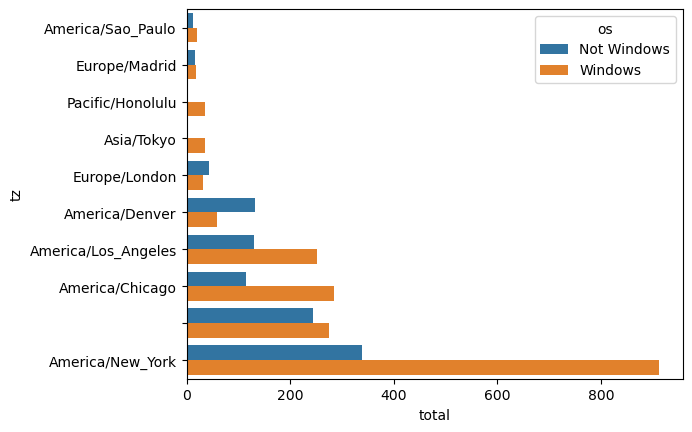

In [68]:
sns.barplot(x='total', y='tz', hue='os', data=count_subset)

The plot doesn’t make it easy to see the relative percentage of Windows users in the
smaller groups, so let’s normalize the group percentages to sum to 1:

In [69]:
def norm_total(group):
    group['normed_total'] = group.total / group.total.sum()
    return group

In [70]:
results = count_subset.groupby('tz').apply(norm_total)

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\652843244.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = count_subset.groupby('tz').apply(norm_total)


Then plot this

<Axes: xlabel='normed_total', ylabel='tz'>

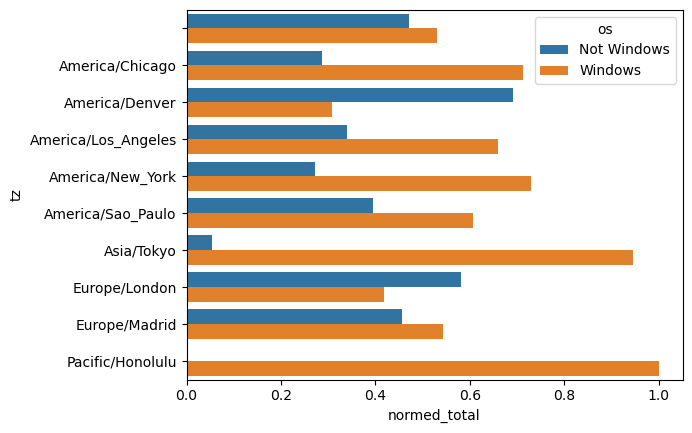

In [71]:
sns.barplot(x='normed_total', y='tz', hue='os', data=results)

We could have computed the normalized sum more efficiently by using the `transform` method with groupby:

In [72]:
g = count_subset.groupby('tz')

In [73]:
results2 = count_subset.total / g.total.transform('sum')

In [74]:
results2

0     0.393939
1     0.606061
2     0.457143
3     0.542857
4     0.000000
5     1.000000
6     0.054054
7     0.945946
8     0.581081
9     0.418919
10    0.691099
11    0.308901
12    0.340314
13    0.659686
14    0.287500
15    0.712500
16    0.470250
17    0.529750
18    0.270983
19    0.729017
Name: total, dtype: float64

In [75]:
g

In [76]:
g.total.transform('sum')

0       33.0
1       33.0
2       35.0
3       35.0
4       36.0
5       36.0
6       37.0
7       37.0
8       74.0
9       74.0
10     191.0
11     191.0
12     382.0
13     382.0
14     400.0
15     400.0
16     521.0
17     521.0
18    1251.0
19    1251.0
Name: total, dtype: float64

## 14.2 MovieLens 1M Dataset

[GroupLens Research](http://www.grouplens.org/node/73) provides a number of collections of movie ratings data collected
from users of MovieLens in the late 1990s and early 2000s. The data provide movie
ratings, movie metadata (genres and year), and demographic data about the users
(age, zip code, gender identification, and occupation). Such data is often of interest in
the development of recommendation systems based on machine learning algorithms.
While we do not explore machine learning techniques in detail in this book, I will
show you how to slice and dice datasets like these into the exact form you need.

The MovieLens 1M dataset contains 1 million ratings collected from 6,000 users on
4,000 movies. It’s spread across three tables: ratings, user information, and movie
information. After extracting the data from the ZIP file, we can load each table into a
pandas DataFrame object using `pandas.read_table`:

In [77]:
import pandas as pd

In [78]:
pd.options.display.max_rows = 10

In [79]:
unames = ['user_id', 'gender', 'age', 'occupation', 'zip']

In [80]:
users = pd.read_table('data/movielens/users.dat', sep='::',header=None, names=unames)

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\1762353854.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  users = pd.read_table('data/movielens/users.dat', sep='::',header=None, names=unames)


In [81]:
rnames = ['user_id', 'movie_id', 'rating', 'timestamp']

In [82]:
ratings = pd.read_table('data/movielens/ratings.dat', sep='::',
header=None, names=rnames)

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\3074888370.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  ratings = pd.read_table('data/movielens/ratings.dat', sep='::',


In [83]:
mnames = ['movie_id', 'title', 'genres']

In [84]:
movies = pd.read_table('data/movielens/movies.dat', sep='::',header=None, names=mnames)

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\2616527196.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  movies = pd.read_table('data/movielens/movies.dat', sep='::',header=None, names=mnames)


You can verify that everything succeeded by looking at the first few rows of each
DataFrame with Python’s slice syntax:

In [85]:
users[:5]

,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [86]:
ratings[:5]

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [87]:
movies[:5]

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [88]:
ratings

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


Note that ages and occupations are coded as integers indicating groups described in
the dataset’s *README* file. Analyzing the data spread across three tables is not a simple
task; for example, suppose you wanted to compute mean ratings for a particular
movie by sex and age. As you will see, this is much easier to do with all of the data
merged together into a single table. Using pandas’s `merge` function, we first merge
`ratings` with`users` and then merge that result with the `movies` data. `pandas` infers
which columns to use as the merge (or join) keys based on overlapping names:

In [89]:
data = pd.merge(pd.merge(ratings, users), movies)

In [90]:
data.iloc[0]

user_id                                            1
movie_id                                        1193
rating                                             5
timestamp                                  978300760
gender                                             F
age                                                1
occupation                                        10
zip                                            48067
title         One Flew Over the Cuckoo's Nest (1975)
genres                                         Drama
Name: 0, dtype: object

To get mean movie ratings for each film grouped by gender, we can use the `pivot_table` method:

In [91]:
mean_ratings = data.pivot_table('rating', index='title',columns='gender', aggfunc='mean')

In [92]:
mean_ratings[:5]

gender,F,M
title,,
"$1,000,000 Duck (1971)",3.375000,2.761905
'Night Mother (1986),3.388889,3.352941
'Til There Was You (1997),2.675676,2.733333
"'burbs, The (1989)",2.793478,2.962085
...And Justice for All (1979),3.828571,3.689024


This produced another DataFrame containing mean ratings with movie titles as row
labels (the “index”) and gender as column labels.

I first filter down to movies that received at least 250 ratings (a completely arbitrary number); to do this, I then group
the data by title and use `size()` to get a Series of group sizes for each title:

In [93]:
ratings_by_title = data.groupby('title').size()

In [94]:
ratings_by_title[:10]

title
$1,000,000 Duck (1971)                37
'Night Mother (1986)                  70
'Til There Was You (1997)             52
'burbs, The (1989)                   303
...And Justice for All (1979)        199
1-900 (1994)                           2
10 Things I Hate About You (1999)    700
101 Dalmatians (1961)                565
101 Dalmatians (1996)                364
12 Angry Men (1957)                  616
dtype: int64

In [95]:
active_titles = ratings_by_title.index[ratings_by_title >= 250]

In [96]:
active_titles

Index([''burbs, The (1989)', '10 Things I Hate About You (1999)',
       '101 Dalmatians (1961)', '101 Dalmatians (1996)', '12 Angry Men (1957)',
       '13th Warrior, The (1999)', '2 Days in the Valley (1996)',
       '20,000 Leagues Under the Sea (1954)', '2001: A Space Odyssey (1968)',
       '2010 (1984)',
       ...
       'X-Men (2000)', 'Year of Living Dangerously (1982)',
       'Yellow Submarine (1968)', 'You've Got Mail (1998)',
       'Young Frankenstein (1974)', 'Young Guns (1988)',
       'Young Guns II (1990)', 'Young Sherlock Holmes (1985)',
       'Zero Effect (1998)', 'eXistenZ (1999)'],
      dtype='object', name='title', length=1216)

The index of titles receiving at least 250 ratings can then be used to select rows from
`mean_ratings`:

In [97]:
mean_ratings = mean_ratings.loc[active_titles]

In [98]:
mean_ratings

gender,F,M
title,,
"'burbs, The (1989)",2.793478,2.962085
10 Things I Hate About You (1999),3.646552,3.311966
101 Dalmatians (1961),3.791444,3.500000
101 Dalmatians (1996),3.240000,2.911215
12 Angry Men (1957),4.184397,4.328421
...,...,...
Young Guns (1988),3.371795,3.425620
Young Guns II (1990),2.934783,2.904025
Young Sherlock Holmes (1985),3.514706,3.363344


To see the top films among female viewers, we can sort by the F column in descending
order:

In [99]:
top_female_ratings = mean_ratings.sort_values(by='F', ascending=False)

In [100]:
top_female_ratings[:10]

gender,F,M
title,,
"Close Shave, A (1995)",4.644444,4.473795
"Wrong Trousers, The (1993)",4.588235,4.478261
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.572650,4.464589
Wallace & Gromit: The Best of Aardman Animation (1996),4.563107,4.385075
Schindler's List (1993),4.562602,4.491415
"Shawshank Redemption, The (1994)",4.539075,4.560625
"Grand Day Out, A (1992)",4.537879,4.293255
To Kill a Mockingbird (1962),4.536667,4.372611
Creature Comforts (1990),4.513889,4.272277


### Measuring Rating Disagreement

Suppose you wanted to find the movies that are most divisive between male and
female viewers. One way is to add a column to `mean_ratings` containing the difference
in means, then sort by that:

In [101]:
mean_ratings['diff'] = mean_ratings['M'] - mean_ratings['F']

Sorting by `'diff'` yields the movies with the greatest rating difference so that we can
see which ones were preferred by women

In [102]:
sorted_by_diff = mean_ratings.sort_values(by='diff')

In [103]:
sorted_by_diff[:10]

gender,F,M,diff
title,,,
Dirty Dancing (1987),3.790378,2.959596,-0.830782
Jumpin' Jack Flash (1986),3.254717,2.578358,-0.676359
Grease (1978),3.975265,3.367041,-0.608224
Little Women (1994),3.870588,3.321739,-0.548849
Steel Magnolias (1989),3.901734,3.365957,-0.535777
Anastasia (1997),3.800000,3.281609,-0.518391
"Rocky Horror Picture Show, The (1975)",3.673016,3.160131,-0.512885
"Color Purple, The (1985)",4.158192,3.659341,-0.498851
"Age of Innocence, The (1993)",3.827068,3.339506,-0.487561


Reversing the order of the rows and again slicing off the top 10 rows, we get the movies
preferred by men that women didn’t rate as highly:

In [104]:
# Reverse order of rows, take first 10 rows
In [90]: sorted_by_diff[::-1][:10]

gender,F,M,diff
title,,,
"Good, The Bad and The Ugly, The (1966)",3.494949,4.221300,0.726351
"Kentucky Fried Movie, The (1977)",2.878788,3.555147,0.676359
Dumb & Dumber (1994),2.697987,3.336595,0.638608
"Longest Day, The (1962)",3.411765,4.031447,0.619682
"Cable Guy, The (1996)",2.250000,2.863787,0.613787
Evil Dead II (Dead By Dawn) (1987),3.297297,3.909283,0.611985
"Hidden, The (1987)",3.137931,3.745098,0.607167
Rocky III (1982),2.361702,2.943503,0.581801
Caddyshack (1980),3.396135,3.969737,0.573602


Suppose instead you wanted the movies that elicited the most disagreement among
viewers, independent of gender identification. Disagreement can be measured by the
variance or standard deviation of the ratings:

In [105]:
rating_std_by_title = data.groupby('title')['rating'].std()

In [106]:
rating_std_by_title = rating_std_by_title.loc[active_titles]

In [107]:
rating_std_by_title.sort_values(ascending=False)[:10]

title
Dumb & Dumber (1994)                     1.321333
Blair Witch Project, The (1999)          1.316368
Natural Born Killers (1994)              1.307198
Tank Girl (1995)                         1.277695
Rocky Horror Picture Show, The (1975)    1.260177
Eyes Wide Shut (1999)                    1.259624
Evita (1996)                             1.253631
Billy Madison (1995)                     1.249970
Fear and Loathing in Las Vegas (1998)    1.246408
Bicentennial Man (1999)                  1.245533
Name: rating, dtype: float64

You may have noticed that movie genres are given as a pipe-separated (|) string. If
you wanted to do some analysis by genre, more work would be required to transform
the genre information into a more usable form.

### 14.3 US Baby Names 1880–2010

The United States Social Security Administration (SSA) has made available data on
the frequency of baby names from 1880 through the present. Hadley Wickham, an
author of several popular R packages, has often made use of this dataset in illustrating
data manipulation in R.

There are many things you might want to do with the dataset:
* Visualize the proportion of babies given a particular name (your own, or another
name) over time
* Determine the relative rank of a name
* Determine the most popular names in each year or the names whose popularity
has advanced or declined the most
* Analyze trends in names: vowels, consonants, length, overall diversity, changes in
spelling, first and last letters
* Analyze external sources of trends: biblical names, celebrities, demographic
changes

With the tools in this book, many of these kinds of analyses are within reach, so I will
walk you through some of them.

As of this writing, the US Social Security Administration makes available data files,
one per year, containing the total number of births for each sex/name combination.
The raw archive of these files can be obtained from http://www.ssa.gov/oact/baby
names/limits.html.

<div class="blue box" 
New location : https://www.ssa.gov/oact/babynames/names.zip



New location : https://www.ssa.gov/oact/babynames/names.zip

In [108]:
names1880 = pd.read_csv('data/babynames/names/yob1880.txt',names=['name', 'sex', 'births'])

In [109]:
names1880

,name,sex,births
0,Mary,F,7065
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939
4,Minnie,F,1746
...,...,...,...
1995,Woodie,M,5
1996,Worthy,M,5
1997,Wright,M,5
1998,York,M,5


These files only contain names with at least five occurrences in each year, so for simplicity’s
sake we can use the sum of the births column by sex as the total number of
births in that year:

In [110]:
names1880.groupby('sex').births.sum()

sex
F     90994
M    110490
Name: births, dtype: int64

Since the dataset is split into files by year, one of the first things to do is to assemble
all of the data into a single DataFrame and further to add a year field. You can do this
using `pandas.concat`:

In [111]:
years = range(1880, 2011)
pieces = []
columns = ['name', 'sex', 'births']
for year in years:
    path = 'data/babynames/names/yob%d.txt' % year
    frame = pd.read_csv(path, names=columns)
    frame['year'] = year
    pieces.append(frame)
# Concatenate everything into a single DataFrame
names = pd.concat(pieces, ignore_index=True)

There are a couple things to note here. First, remember that concat glues the Data‐
Frame objects together row-wise by default. Secondly, you have to pass
`ignore_index=True` because we’re not interested in preserving the original row numbers
returned from read_csv. So we now have a very large DataFrame containing all
of the names data:

In [112]:
names

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
1692627,Zymaire,M,5,2010
1692628,Zyonne,M,5,2010
1692629,Zyquarius,M,5,2010
1692630,Zyran,M,5,2010


With this data in hand, we can already start aggregating the data at the year and sex
level using groupby or pivot_table 

In [113]:
total_births = names.pivot_table('births', index='year',columns='sex', aggfunc=sum)

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\12788037.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  total_births = names.pivot_table('births', index='year',columns='sex', aggfunc=sum)


In [114]:
total_births.tail()

sex,F,M
year,,
2006,1901070,2055119
2007,1922448,2075235
2008,1890718,2039947
2009,1836870,1983305
2010,1777327,1918412


<Axes: title={'center': 'Total births by sex and year'}, xlabel='year'>

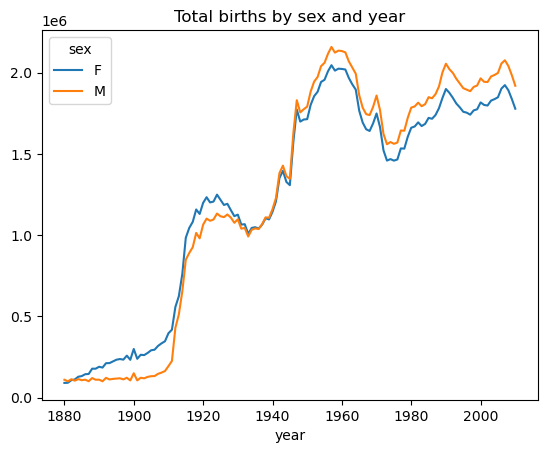

In [115]:
total_births.plot(title='Total births by sex and year')

Next, let’s insert a column  `prop` with the fraction of babies given each name relative to
the total number of births. A `prop` value of `0.02` would indicate that 2 out of every
100 babies were given a particular name. Thus, we group the data by year and sex,
then add the new column to each group:

In [116]:
def add_prop(group):
    group['prop'] = group.births / group.births.sum()
    return group

    
names = names.groupby(['year', 'sex']).apply(
    add_prop)

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\4022619589.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  names = names.groupby(['year', 'sex']).apply(


The resulting complete dataset now has the following columns:

In [117]:
names

name sex  births  year      prop
year sex                                               
1880 F   0             Mary   F    7065  1880  0.077642
         1             Anna   F    2604  1880  0.028617
         2             Emma   F    2003  1880  0.022012
         3        Elizabeth   F    1939  1880  0.021309
         4           Minnie   F    1746  1880  0.019188
...                     ...  ..     ...   ...       ...
2010 M   1692627    Zymaire   M       5  2010  0.000003
         1692628     Zyonne   M       5  2010  0.000003
         1692629  Zyquarius   M       5  2010  0.000003
         1692630      Zyran   M       5  2010  0.000003
         1692631      Zzyzx   M       5  2010  0.000003

[1692632 rows x 5 columns]

When performing a group operation like this, it’s often valuable to do a sanity check,
like verifying that the `prop` column sums to 1 within all the groups:

In [118]:
names = names.reset_index(drop=True)

In [119]:
names

,name,sex,births,year,prop
0,Mary,F,7065,1880,0.077642
1,Anna,F,2604,1880,0.028617
2,Emma,F,2003,1880,0.022012
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...
1692627,Zymaire,M,5,2010,0.000003
1692628,Zyonne,M,5,2010,0.000003
1692629,Zyquarius,M,5,2010,0.000003
1692630,Zyran,M,5,2010,0.000003


In [120]:
names.groupby(['year', 'sex']).prop.sum()

year  sex
1880  F      1.0
      M      1.0
1881  F      1.0
      M      1.0
1882  F      1.0
            ... 
2008  M      1.0
2009  F      1.0
      M      1.0
2010  F      1.0
      M      1.0
Name: prop, Length: 262, dtype: float64

Now that this is done, I’m going to extract a subset of the data to facilitate further
analysis: the top 1,000 names for each sex/year combination. This is yet another
group operation:

In [121]:
def get_top1000(group):
    return group.sort_values(by='births', ascending=False)[:1000]
 
grouped = names.groupby(['year', 'sex'])
top1000 = grouped.apply(get_top1000)
# Drop the group index, not needed
# top1000.reset_index(inplace=True, drop=True)

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\1575589899.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top1000 = grouped.apply(get_top1000)


In [122]:
top1000

name sex  births  year      prop
year sex                                               
1880 F   0             Mary   F    7065  1880  0.077642
         1             Anna   F    2604  1880  0.028617
         2             Emma   F    2003  1880  0.022012
         3        Elizabeth   F    1939  1880  0.021309
         4           Minnie   F    1746  1880  0.019188
...                     ...  ..     ...   ...       ...
2010 M   1679358        Taj   M     197  2010  0.000103
         1679360     Bailey   M     196  2010  0.000102
         1679361     Destin   M     196  2010  0.000102
         1679362    Eliezer   M     196  2010  0.000102
         1679363      Enoch   M     196  2010  0.000102

[261876 rows x 5 columns]

In [123]:
top1000.reset_index(inplace=True, drop=True)

In [124]:
top1000

,name,sex,births,year,prop
0,Mary,F,7065,1880,0.077642
1,Anna,F,2604,1880,0.028617
2,Emma,F,2003,1880,0.022012
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...
261871,Taj,M,197,2010,0.000103
261872,Bailey,M,196,2010,0.000102
261873,Destin,M,196,2010,0.000102
261874,Eliezer,M,196,2010,0.000102


We’ll use this Top 1,000 dataset in the following investigations into the data.

### Analyzing Naming Trends

With the full dataset and Top 1,000 dataset in hand, we can start analyzing various
naming trends of interest. Splitting the Top 1,000 names into the boy and girl portions
is easy to do first:

In [125]:
boys = top1000[top1000.sex == 'M']

In [126]:
girls = top1000[top1000.sex == 'F']

Simple time series, like the number of Johns or Marys for each year, can be plotted
but require a bit of munging to be more useful. Let’s form a pivot table of the total
number of births by year and namem

In [127]:
total_births = top1000.pivot_table('births', index='year',columns='name',aggfunc=sum)

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\34375187.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  total_births = top1000.pivot_table('births', index='year',columns='name',aggfunc=sum)


Now, this can be plotted for a handful of names with DataFrame’s plot method

In [128]:
total_births

name,Aaden,Aaliyah,Aarav,Aaron,Aarush,Ab,Abagail,Abb,Abbey,Abbie,...,Zoa,Zoe,Zoey,Zoie,Zola,Zollie,Zona,Zora,Zula,Zuri
year,,,,,,,,,,,,,,,,,,,,,
1880,NaN,NaN,NaN,102.0,NaN,NaN,NaN,NaN,NaN,71.0,...,8.0,23.0,NaN,NaN,7.0,NaN,8.0,28.0,27.0,NaN
1881,NaN,NaN,NaN,94.0,NaN,NaN,NaN,NaN,NaN,81.0,...,NaN,22.0,NaN,NaN,10.0,NaN,9.0,21.0,27.0,NaN
1882,NaN,NaN,NaN,85.0,NaN,NaN,NaN,NaN,NaN,80.0,...,8.0,25.0,NaN,NaN,9.0,NaN,17.0,32.0,21.0,NaN
1883,NaN,NaN,NaN,105.0,NaN,NaN,NaN,NaN,NaN,79.0,...,NaN,23.0,NaN,NaN,10.0,NaN,11.0,35.0,25.0,NaN
1884,NaN,NaN,NaN,97.0,NaN,NaN,NaN,NaN,NaN,98.0,...,13.0,31.0,NaN,NaN,14.0,6.0,8.0,58.0,27.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006,NaN,3745.0,NaN,8309.0,NaN,NaN,298.0,NaN,404.0,440.0,...,NaN,5153.0,2858.0,531.0,NaN,NaN,NaN,NaN,NaN,NaN
2007,NaN,3960.0,NaN,8947.0,NaN,NaN,314.0,NaN,349.0,469.0,...,NaN,4937.0,3044.0,527.0,NaN,NaN,NaN,NaN,NaN,NaN
2008,958.0,4045.0,219.0,8545.0,NaN,NaN,321.0,NaN,344.0,401.0,...,NaN,4781.0,3449.0,494.0,NaN,NaN,NaN,NaN,NaN,NaN


In [129]:
total_births.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 1880 to 2010
Columns: 6865 entries, Aaden to Zuri
dtypes: float64(6865)
memory usage: 6.9 MB


In [130]:
subset = total_births[['John', 'Harry', 'Mary', 'Marilyn']]

array([<Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>], dtype=object)

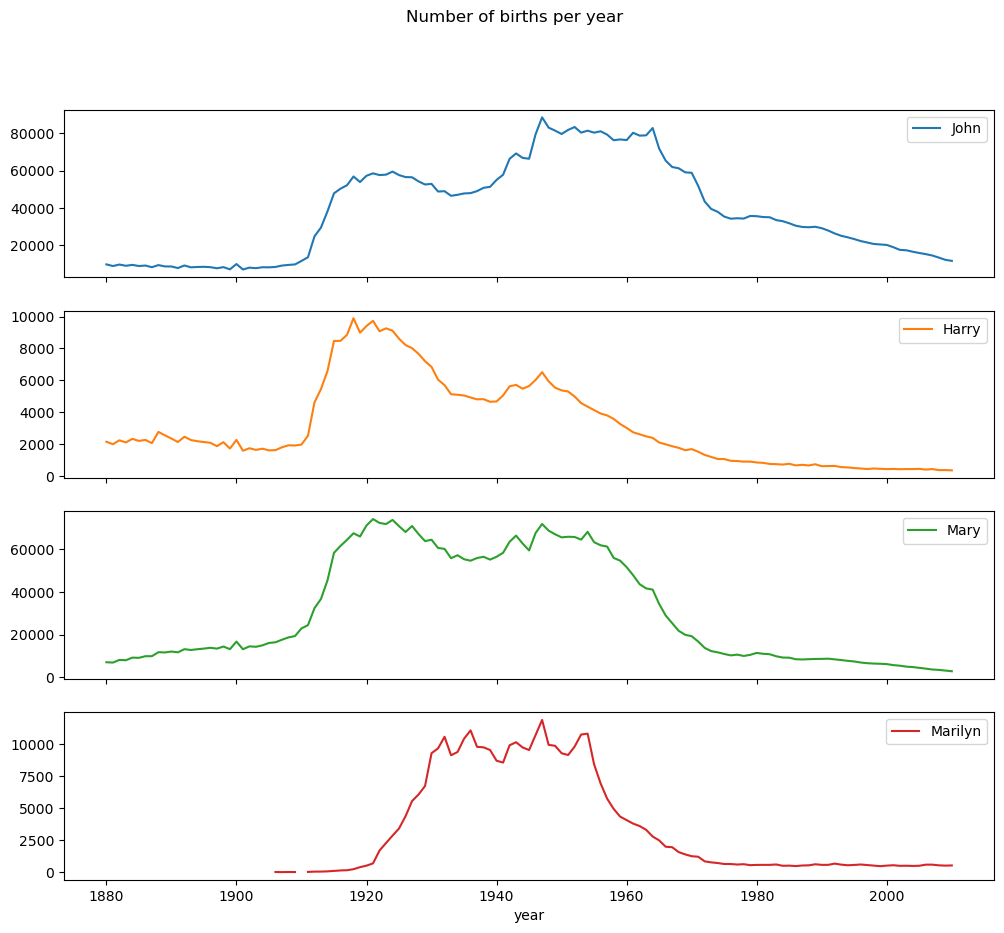

In [131]:
subset.plot(subplots=True, figsize=(12, 10), grid=False,title="Number of births per year")

#### Measuring the increase in naming diversity

One explanation for the decrease in plots is that fewer parents are choosing common
names for their children. This hypothesis can be explored and confirmed in the data.
One measure is the proportion of births represented by the top 1,000 most popular
names, which I aggregate and plot by year and sex.

In [135]:
table = top1000.pivot_table('prop', index='year',columns='sex', aggfunc='sum')

In [136]:
table

sex,F,M
year,,
1880,1.000000,0.997375
1881,1.000000,1.000000
1882,0.998702,0.995646
1883,0.997596,0.998566
1884,0.993156,0.994539
...,...,...
2006,0.753008,0.860250
2007,0.745810,0.855066
2008,0.740775,0.849948


<Axes: title={'center': 'Sum of table1000.prop by year and sex'}, xlabel='year'>

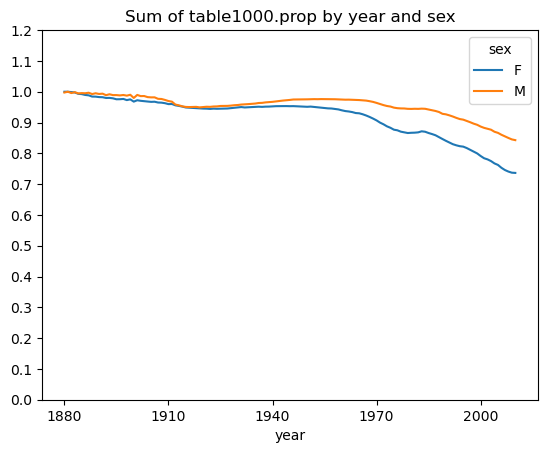

In [140]:
table.plot(title='Sum of table1000.prop by year and sex',
           yticks=np.linspace(0, 1.2, 13), 
           xticks=range(1880, 2020, 30)
          )

You can see that, indeed, there appears to be increasing name diversity (decreasing
total proportion in the top 1,000). Another interesting metric is the number of distinct
names, taken in order of popularity from highest to lowest, in the top 50% of
births. This number is a bit more tricky to compute. Let’s consider just the boy names
from 2010:

In [141]:
df = boys[boys.year == 2010]

In [142]:
df

,name,sex,births,year,prop
260876,Jacob,M,22154,2010,0.011548
260877,Ethan,M,18017,2010,0.009392
260878,Michael,M,17381,2010,0.009060
260879,Jayden,M,17200,2010,0.008966
260880,William,M,17071,2010,0.008899
...,...,...,...,...,...
261871,Taj,M,197,2010,0.000103
261872,Bailey,M,196,2010,0.000102
261873,Destin,M,196,2010,0.000102
261874,Eliezer,M,196,2010,0.000102


After sorting `prop` in descending order, we want to know how many of the most popular
names it takes to reach 50%. You could write a `for` loop to do this, but a vectorized
NumPy way is a bit more clever. Taking the cumulative sum, `cumsum`, of `prop` and
then calling the method `searchsorted` returns the position in the cumulative sum at
which 0.5 would need to be inserted to keep it in sorted order:

In [143]:
prop_cumsum = df.sort_values(by='prop', ascending=False).prop.cumsum()

In [144]:
prop_cumsum[:10]

260876    0.011548
260877    0.020940
260878    0.030000
260879    0.038966
260880    0.047864
260881    0.056604
260882    0.065194
260883    0.073463
260884    0.081567
260885    0.089651
Name: prop, dtype: float64

In [146]:
prop_cumsum.values.searchsorted(0.5)+1

np.int64(117)

Since arrays are zero-indexed, adding 1 to this result gives you a result of 117. By contrast,
in 1900 this number was much smaller:

In [148]:
df = boys[boys.year == 1900]

In [149]:
in1900 = df.sort_values(by='prop', ascending=False).prop.cumsum()

In [150]:
in1900.values.searchsorted(0.5) + 1

np.int64(25)

You can now apply this operation to each year/sex combination, groupby those fields,
and `apply` a function returning the count for each group:

In [151]:
def get_quantile_count(group, q=0.5):
    group = group.sort_values(by='prop', ascending=False)
    return group.prop.cumsum().values.searchsorted(q) + 1

In [153]:
diversity = top1000.groupby(['year', 'sex']).apply(get_quantile_count,include_groups=False)

In [154]:
diversity

year  sex
1880  F       38
      M       14
1881  F       38
      M       14
1882  F       38
            ... 
2008  M      109
2009  F      241
      M      114
2010  F      246
      M      117
Length: 262, dtype: int64

In [155]:
diversity = diversity.unstack('sex')

In [156]:
diversity

sex,F,M
year,,
1880,38,14
1881,38,14
1882,38,15
1883,39,15
1884,39,16
...,...,...
2006,210,99
2007,223,103
2008,234,109


This resulting DataFrame `diversity` now has two time series, one for each sex,
indexed by year. This can be inspected in IPython and plotted as before

In [157]:
diversity.head()

sex,F,M
year,,
1880,38,14
1881,38,14
1882,38,15
1883,39,15
1884,39,16


<Axes: title={'center': 'Number of popular names in top 50%'}, xlabel='year'>

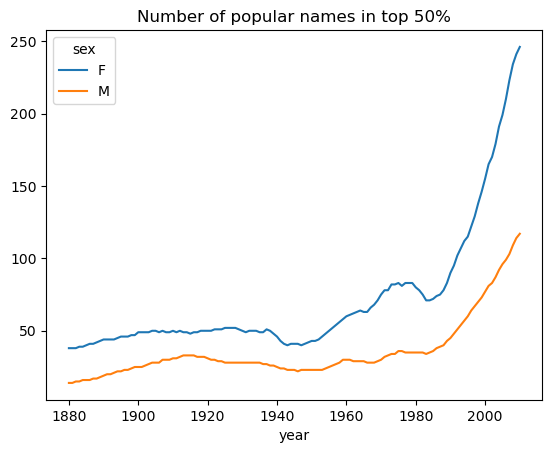

In [158]:
diversity.plot(title="Number of popular names in top 50%")

As you can see, girl names have always been more diverse than boy names, and they
have only become more so over time. Further analysis of what exactly is driving the
diversity, like the increase of alternative spellings, is left to the reader.

#### The “last letter” revolution

In [ ]:
In 2007, baby name researcher Laura Wattenberg pointed out on her website that the
distribution of boy names by final letter has changed significantly over the last 100
years. To see this, we first aggregate all of the births in the full dataset by year, sex, and
final letter:



In [160]:
get_last_letter = lambda x: x[-1]

In [161]:
names

,name,sex,births,year,prop
0,Mary,F,7065,1880,0.077642
1,Anna,F,2604,1880,0.028617
2,Emma,F,2003,1880,0.022012
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...
1692627,Zymaire,M,5,2010,0.000003
1692628,Zyonne,M,5,2010,0.000003
1692629,Zyquarius,M,5,2010,0.000003
1692630,Zyran,M,5,2010,0.000003


In [162]:
last_letters = names.name.map(get_last_letter)

In [164]:
last_letters.name = 'last_letter'

In [165]:
last_letters

0          y
1          a
2          a
3          h
4          e
          ..
1692627    e
1692628    e
1692629    s
1692630    n
1692631    x
Name: last_letter, Length: 1692632, dtype: object

In [167]:
table = names.pivot_table('births', index=last_letters,
columns=['sex', 'year'], aggfunc='sum')

In [168]:
table

sex                F                                                        \
year            1880     1881     1882     1883     1884     1885     1886   
last_letter                                                                  
a            31446.0  31581.0  36536.0  38330.0  43680.0  45408.0  49100.0   
b                NaN      NaN      NaN      NaN      NaN      NaN      NaN   
c                NaN      NaN      5.0      5.0      NaN      NaN      NaN   
d              609.0    607.0    734.0    810.0    916.0    862.0   1007.0   
e            33381.0  34080.0  40399.0  41914.0  48089.0  49616.0  53883.0   
...              ...      ...      ...      ...      ...      ...      ...   
v                NaN      NaN      NaN      NaN      NaN      NaN      NaN   
w                NaN      5.0      NaN      NaN      NaN      NaN      5.0   
x                NaN      NaN      NaN      7.0      NaN      NaN      NaN   
y            10467.0  10404.0  12143.0  12063.0  13918.0  13927.0  14932.0   
z              106.0     95.0    106.0    141.0    148.0    150.0    202.0   

sex                                     ...         M                      \
year            1887     1888     1889  ...      2001      2002      2003   
last_letter                             ...                                 
a            48941.0  59440.0  58631.0  ...   39176.0   38862.0   37878.0   
b                NaN      NaN      NaN  ...   51028.0   49344.0   48140.0   
c                NaN      NaN      NaN  ...   27135.0   27269.0   27734.0   
d             1027.0   1298.0   1374.0  ...   60941.0   55969.0   53499.0   
e            54353.0  66748.0  66662.0  ...  145560.0  144833.0  144984.0   
...              ...      ...      ...  ...       ...       ...       ...   
v                NaN      NaN      NaN  ...    1210.0    1332.0    1653.0   
w                NaN      NaN      NaN  ...   52322.0   50155.0   49140.0   
x                NaN      NaN      NaN  ...   10697.0   11018.0   11727.0   
y            14980.0  17928.0  17600.0  ...  139320.0  134767.0  130798.0   
z              188.0    238.0    277.0  ...    2845.0    2743.0    2724.0   

sex                                                                      \
year             2004      2005      2006      2007      2008      2009   
last_letter                                                               
a             38727.0   36926.0   36271.0   34780.0   33074.0   31659.0   
b             45985.0   43232.0   42715.0   42282.0   40124.0   39131.0   
c             26810.0   26133.0   26694.0   26933.0   25414.0   24180.0   
d             51890.0   50815.0   51581.0   50796.0   48121.0   46402.0   
e            142315.0  141380.0  143326.0  144126.0  141487.0  136172.0   
...               ...       ...       ...       ...       ...       ...   
v              1823.0    1795.0    2013.0    2298.0    2423.0    2597.0   
w             47616.0   45555.0   43326.0   40370.0   37090.0   33400.0   
x             12416.0   13047.0   14013.0   14349.0   14874.0   16712.0   
y            128620.0  125477.0  124030.0  123780.0  123129.0  113597.0   
z              2713.0    2911.0    3100.0    3310.0    3494.0    3653.0   

sex                    
year             2010  
last_letter            
a             28906.0  
b             39320.0  
c             23378.0  
d             44876.0  
e            130395.0  
...               ...  
v              2782.0  
w             31044.0  
x             16493.0  
y            111671.0  
z              3510.0  

[26 rows x 262 columns]

Then we select out three representative years spanning the history and print the first
few rows:

In [170]:
subtable = table.reindex(columns=[1910, 1960, 2010], level='year')

In [171]:
subtable

sex                 F                            M                    
year             1910      1960      2010     1910      1960      2010
last_letter                                                           
a            108399.0  691254.0  677566.0    977.0    5216.0   28906.0
b                 NaN     694.0     455.0    411.0    3913.0   39320.0
c                 5.0      49.0     958.0    482.0   15456.0   23378.0
d              6751.0    3732.0    2645.0  22111.0  262105.0   44876.0
e            133599.0  435000.0  317138.0  28665.0  178731.0  130395.0
...               ...       ...       ...      ...       ...       ...
v                 NaN     122.0     208.0     22.0      77.0    2782.0
w                 8.0      63.0    2116.0   1228.0   16425.0   31044.0
x                 6.0      74.0    1299.0    770.0    3947.0   16493.0
y             44002.0  308438.0  207497.0  15021.0  343282.0  111671.0
z               966.0    1330.0    1244.0     33.0     391.0    3510.0

[26 rows x 6 columns]

Next, normalize the table by total births to compute a new table containing proportion
of total births for each sex ending in each letter:

In [173]:
subtable.sum()

sex  year
F    1910     396503.0
     1960    2021900.0
     2010    1777327.0
M    1910     194208.0
     1960    2131915.0
     2010    1918412.0
dtype: float64

In [174]:
letter_prop = subtable / subtable.sum()

In [175]:
letter_prop

sex                 F                             M                    
year             1910      1960      2010      1910      1960      2010
last_letter                                                            
a            0.273388  0.341883  0.381228  0.005031  0.002447  0.015068
b                 NaN  0.000343  0.000256  0.002116  0.001835  0.020496
c            0.000013  0.000024  0.000539  0.002482  0.007250  0.012186
d            0.017026  0.001846  0.001488  0.113852  0.122943  0.023392
e            0.336943  0.215144  0.178435  0.147599  0.083836  0.067970
...               ...       ...       ...       ...       ...       ...
v                 NaN  0.000060  0.000117  0.000113  0.000036  0.001450
w            0.000020  0.000031  0.001191  0.006323  0.007704  0.016182
x            0.000015  0.000037  0.000731  0.003965  0.001851  0.008597
y            0.110975  0.152549  0.116747  0.077345  0.161020  0.058210
z            0.002436  0.000658  0.000700  0.000170  0.000183  0.001830

[26 rows x 6 columns]

<details class="collapsible blue-box">
<summary>📘 Click to expand explanation </summary>

```python
letter_prop = subtable / subtable.sum()
```

Let’s break it down carefully from a **pandas internals + data alignment** perspective.

---

## 🔹 1. What does `subtable` look like?

After your pivot + reindex, `subtable` looks like this:

* **Index (rows):** last letters (`a`, `b`, `c`, …)
* **Columns:** MultiIndex → `(sex, year)`

Example structure:

```
sex        F              M
year    1910 1960 2010 1910 1960 2010
a       ...  ...  ...   ...  ...  ...
b       ...  ...  ...   ...  ...  ...
c       ...  ...  ...   ...  ...  ...
```

---

## 🔹 2. What does `subtable.sum()` return?

By default:

```python
subtable.sum()
```

means:

👉 **sum over rows (axis=0)**

So you get:

* One value per column
* Still a **MultiIndex Series**

Example:

```
sex  year
F    1910    120000
     1960    150000
     2010    180000
M    1910    130000
     1960    160000
     2010    170000
dtype: float64
```

So yes — it's **not a table**, it's a **Series with MultiIndex**.

---

## 🔹 3. Now the key: How does division work?

```python
subtable / subtable.sum()
```

This works because of **pandas automatic alignment (broadcasting with labels)**.

### 👉 Rule:

Pandas aligns **by column labels** when operating between:

* DataFrame (subtable)
* Series (subtable.sum())

---

## 🔹 4. What actually happens internally

For each column:

```
(subtable[('F', 1910)]) / (subtable.sum()[('F', 1910)])
```

So:

* Every value in column `(F, 1910)` is divided by the **total births for that column**
* Same for `(F, 1960)`, `(M, 2010)`, etc.

---

## 🔹 5. Result: Column-wise normalization

You are converting counts → proportions:

```
letter_prop = proportion of each last letter per (sex, year)
```

So now:

👉 Each column sums to **1.0**

---

## 🔹 6. Example (simplified)

Before:

```
        ('F', 1910)
a          30000
b          20000
c          50000
```

Sum:

```
('F', 1910) = 100000
```

After division:

```
a = 0.30
b = 0.20
c = 0.50
```

---

## 🔹 7. Why this works (core concept)

This line relies on:

### ✅ Label-based broadcasting

* Pandas does NOT use position
* It uses **MultiIndex column labels**

So even with complex indexes like:

```
('sex', 'year')
```

it matches perfectly.

---

## 🔹 8. Mental Model (Important)

Think of it as:

> “Normalize each column independently”

Equivalent explicit version:

```python
letter_prop = subtable.div(subtable.sum(), axis=1)
```

---

## 🔹 9. Common mistake to avoid

If you accidentally do:

```python
subtable.sum(axis=1)
```

Then you get row sums → and division would behave completely differently (and likely break your logic).

---

## 🔹 Final intuition

This line:

```python
subtable / subtable.sum()
```

👉 transforms **raw counts → probability distribution per (sex, year)**

Which is why later analyses like:

* trends in last letters
* popularity shifts over time

become meaningful.

---


With the letter proportions now in hand, we can make bar plots for each sex broken
down by year

In [177]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'Female'}, xlabel='last_letter'>

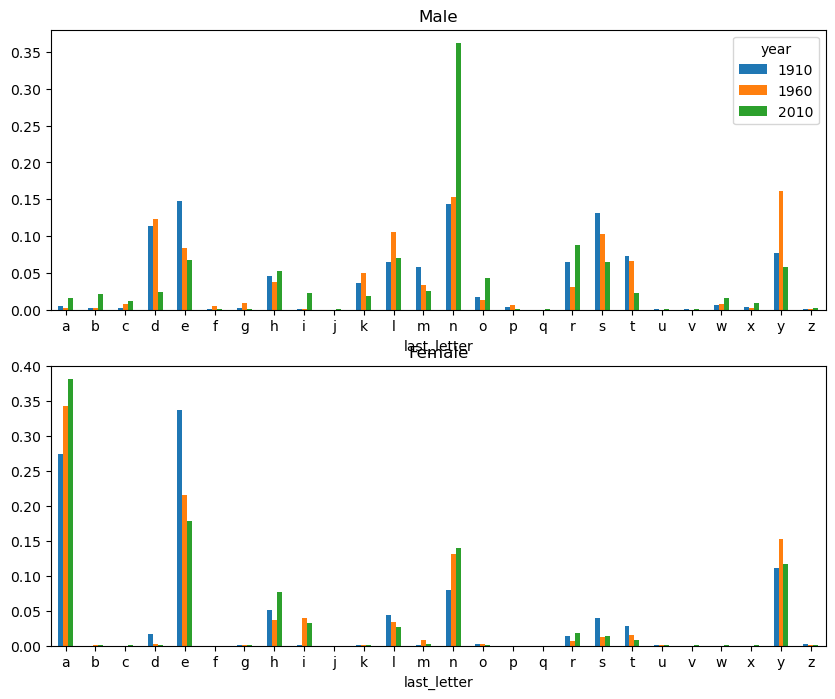

In [181]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
letter_prop['M'].plot(kind='bar', rot=0, ax=axes[0], title='Male')
letter_prop['F'].plot(kind='bar', rot=0, ax=axes[1], title='Female',legend=False)

As you can see, boy names ending in n have experienced significant growth since the
1960s. Going back to the full table created before, I again normalize by year and sex
and select a subset of letters for the boy names, finally transposing to make each column
a time series:

In [182]:
letter_prop = table / table.sum()

In [183]:
djny_ts = letter_prop.loc[['d', 'j', 'n', 'y'], 'M'].T

In [184]:
djny_ts

last_letter,d,j,n,y
year,,,,
1880,0.083057,NaN,0.153217,0.075763
1881,0.083238,NaN,0.153214,0.077461
1882,0.085332,NaN,0.149561,0.077538
1883,0.084053,NaN,0.151656,0.079149
1884,0.086122,NaN,0.149927,0.080408
...,...,...,...,...
2006,0.025099,0.000607,0.351612,0.060352
2007,0.024477,0.000607,0.358212,0.059646
2008,0.023589,0.000679,0.361004,0.060359


With this DataFrame of time series in hand, I can make a plot of the trends over time
again with its plot method

<Axes: xlabel='year'>

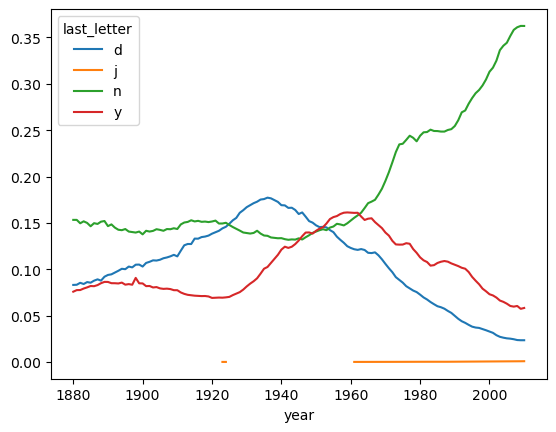

In [187]:
djny_ts.plot()

#### Boy names that became girl names (and vice versa)

Another fun trend is looking at boy names that were more popular with one sex earlier
in the sample but have “changed sexes” in the present. One example is the name
Lesley or Leslie. Going back to the `top1000` DataFrame, I compute a list of names
occurring in the dataset starting with “lesl”:

In [188]:
all_names = pd.Series(top1000.name.unique())

In [189]:
lesley_like = all_names[all_names.str.lower().str.contains('lesl')]

In [190]:
lesley_like

632     Leslie
2293    Lesley
4263    Leslee
4729     Lesli
6102     Lesly
dtype: object

From there, we can filter down to just those names and sum births grouped by name
to see the relative frequencies:

In [191]:
filtered = top1000[top1000.name.isin(lesley_like)]

In [192]:
filtered.groupby('name').births.sum()

name
Leslee      1083
Lesley     35041
Lesli        929
Leslie    370585
Lesly      10073
Name: births, dtype: int64

Next, let’s aggregate by sex and year and normalize within year:

In [194]:
table = filtered.pivot_table('births', index='year',columns='sex', aggfunc='sum')

In [195]:
table

sex,F,M
year,,
1880,8.0,79.0
1881,11.0,92.0
1882,9.0,128.0
1883,7.0,125.0
1884,15.0,125.0
...,...,...
2006,4168.0,NaN
2007,3808.0,NaN
2008,3024.0,NaN


In [196]:
table = table.div(table.sum(1), axis=0)

In [197]:
table

sex,F,M
year,,
1880,0.091954,0.908046
1881,0.106796,0.893204
1882,0.065693,0.934307
1883,0.053030,0.946970
1884,0.107143,0.892857
...,...,...
2006,1.000000,NaN
2007,1.000000,NaN
2008,1.000000,NaN


<details class="collapsible blue-box">
<summary>📘 Click to expand explanation </summary>

You’ve now moved from **column normalization → row normalization**. That last line is doing something slightly different from your previous example.

```python
table = table.div(table.sum(1), axis=0)
```

Let’s unpack it properly.

---

## 🔹 1. What does `table` look like before this line?

After your pivot:

```python
table = filtered.pivot_table(
    'births',
    index='year',
    columns='sex',
    aggfunc='sum'
)
```

Structure:

```text
sex      F      M
year
1910   1200   300
1920   1500   500
...
```

👉 Each row = a year
👉 Columns = total births for that name group by sex

---

## 🔹 2. What does `table.sum(1)` mean?

```python
table.sum(1)
```

* `axis=1` → sum **across columns**
* So you get **total births per year**

Example:

```text
year
1910    1500
1920    2000
...
```

This is a **Series indexed by year**.

---

## 🔹 3. What does `.div(..., axis=0)` do?

```python
table.div(table.sum(1), axis=0)
```

### Key idea:

👉 **Align on index (rows), not columns**

* `axis=0` → match values using the **row index (`year`)**
* So each row gets divided by its **own row total**

---

## 🔹 4. What actually happens internally

For each row:

```python
table.loc[1910] / table.sum(1).loc[1910]
```

So:

```text
F = 1200 / 1500 = 0.8
M = 300  / 1500 = 0.2
```

---

## 🔹 5. Result: Row-wise normalization

After this:

```text
sex      F      M
year
1910   0.80   0.20
1920   0.75   0.25
...
```

👉 Each row now sums to **1.0**

---

## 🔹 6. Why `.div()` instead of `/`?

You *could* write:

```python
table / table.sum(1)
```

But that can be ambiguous.

👉 `.div(..., axis=0)` makes it explicit:

* “Divide row-wise”
* Align using index (`year`)

---

## 🔹 7. Mental model (very important)

This line means:

> “Convert counts into proportions **within each year**”

So now you're answering:

👉 *“In a given year, what fraction of these names were female vs male?”*

---

## 🔹 8. Compare with your previous case

| Case                              | Operation   | Meaning                   |
| --------------------------------- | ----------- | ------------------------- |
| `subtable / subtable.sum()`       | column-wise | normalize per (sex, year) |
| `table.div(table.sum(1), axis=0)` | row-wise    | normalize per year        |

---

## 🔹 9. Equivalent explicit version

```python
row_totals = table.sum(axis=1)
table = table.div(row_totals, axis=0)
```

---

## 🔹 Final intuition

This line transforms:

👉 **absolute counts → gender ratio per year**

Which is exactly what you want to track:

> “How did ‘Lesley-like’ names shift between male and female over time?”

---


Lastly, it’s now possible to make a plot of the breakdown by sex over time.

<Axes: xlabel='year'>

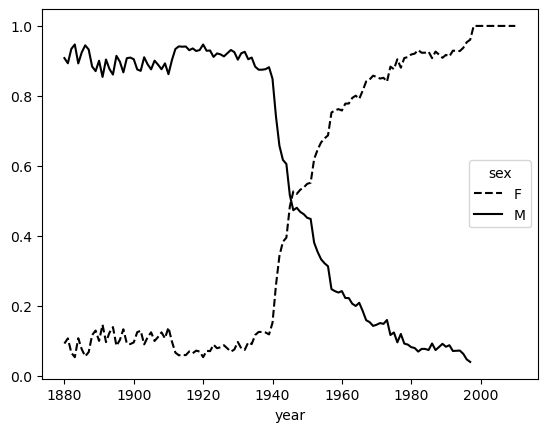

In [199]:
table.plot(style={'M': 'k-', 'F': 'k--'})

## 14.4 USDA Food Database

The US Department of Agriculture makes available a database of food nutrient information.
Programmer Ashley Williams made available a version of this database in
JSON format. 

Each food has a number of identifying attributes along with two lists of nutrients and
portion sizes. Data in this form is not particularly amenable to analysis, so we need to
do some work to wrangle the data into a better form.

After downloading and extracting the data from the link, you can load it into Python
with any JSON library of your choosing. I’ll use the built-in Python `json` module:

In [200]:
import json

In [201]:
db = json.load(open('data/usda_food/database.json'))

In [202]:
len(db)

6636

In [212]:
type(db)

list

In [204]:
db[0].keys()

dict_keys(['id', 'description', 'tags', 'manufacturer', 'group', 'portions', 'nutrients'])

In [217]:
db[0]['description']

'Cheese, caraway'

In [218]:
db[0]['nutrients']

[{'value': 25.18,
  'units': 'g',
  'description': 'Protein',
  'group': 'Composition'},
 {'value': 29.2,
  'units': 'g',
  'description': 'Total lipid (fat)',
  'group': 'Composition'},
 {'value': 3.06,
  'units': 'g',
  'description': 'Carbohydrate, by difference',
  'group': 'Composition'},
 {'value': 3.28, 'units': 'g', 'description': 'Ash', 'group': 'Other'},
 {'value': 376.0, 'units': 'kcal', 'description': 'Energy', 'group': 'Energy'},
 {'value': 39.28,
  'units': 'g',
  'description': 'Water',
  'group': 'Composition'},
 {'value': 1573.0, 'units': 'kJ', 'description': 'Energy', 'group': 'Energy'},
 {'value': 0.0,
  'units': 'g',
  'description': 'Fiber, total dietary',
  'group': 'Composition'},
 {'value': 673.0,
  'units': 'mg',
  'description': 'Calcium, Ca',
  'group': 'Elements'},
 {'value': 0.64,
  'units': 'mg',
  'description': 'Iron, Fe',
  'group': 'Elements'},
 {'value': 22.0,
  'units': 'mg',
  'description': 'Magnesium, Mg',
  'group': 'Elements'},
 {'value': 490.0,

In [214]:
nutrients = pd.DataFrame(db[0]['nutrients'])

In [215]:
nutrients[:7]

,value,units,description,group
0,25.18,g,Protein,Composition
1,29.20,g,Total lipid (fat),Composition
2,3.06,g,"Carbohydrate, by difference",Composition
3,3.28,g,Ash,Other
4,376.00,kcal,Energy,Energy
5,39.28,g,Water,Composition
6,1573.00,kJ,Energy,Energy


(note that this is nutrient listing only for the food item in list position 0)

When converting a list of dicts to a DataFrame, we can specify a list of fields to
extract. We’ll take the food names, group, ID, and manufacturer:

In [219]:
info_keys = ['description', 'group', 'id', 'manufacturer']

In [220]:
info = pd.DataFrame(db, columns=info_keys)

In [221]:
info

,description,group,id,manufacturer
0,"Cheese, caraway",Dairy and Egg Products,1008,
1,"Cheese, cheddar",Dairy and Egg Products,1009,
2,"Cheese, edam",Dairy and Egg Products,1018,
3,"Cheese, feta",Dairy and Egg Products,1019,
4,"Cheese, mozzarella, part skim milk",Dairy and Egg Products,1028,
...,...,...,...,...
6631,"Bologna, beef, low fat",Sausages and Luncheon Meats,42161,
6632,"Turkey and pork sausage, fresh, bulk, patty or...",Sausages and Luncheon Meats,42173,
6633,"Babyfood, juice, pear",Baby Foods,43408,None
6634,"Babyfood, dessert, banana yogurt, strained",Baby Foods,43539,None


In [222]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6636 entries, 0 to 6635
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   description   6636 non-null   object
 1   group         6636 non-null   object
 2   id            6636 non-null   int64 
 3   manufacturer  5195 non-null   object
dtypes: int64(1), object(3)
memory usage: 207.5+ KB


You can see the distribution of food groups with `value_counts`:

In [223]:
pd.value_counts(info.group)[:10]

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\1315169705.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(info.group)[:10]


group
Vegetables and Vegetable Products    812
Beef Products                        618
Baked Products                       496
Breakfast Cereals                    403
Legumes and Legume Products          365
Fast Foods                           365
Lamb, Veal, and Game Products        345
Sweets                               341
Fruits and Fruit Juices              328
Pork Products                        328
Name: count, dtype: int64

In [224]:
pd.Series(info.group).value_counts()

group
Vegetables and Vegetable Products    812
Beef Products                        618
Baked Products                       496
Breakfast Cereals                    403
Legumes and Legume Products          365
                                    ... 
Dairy and Egg Products               107
Fats and Oils                         97
Meals, Entrees, and Sidedishes        57
Restaurant Foods                      51
Spices and Herbs                      41
Name: count, Length: 25, dtype: int64

I need to get Nutrient Info for all gfood items now. Note: I created this function to read both  Food and Nutrients.

In [239]:
import json
import pandas as pd


def load_foods_and_nutrients(file_path):
    """
    Returns:
    info -> ['description', 'group', 'id', 'manufacturer']
    nutrients -> ['description', 'group', 'units', 'value', 'id']
    """

    # Step 1: Load JSON
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Step 2: Prepare containers
    food_rows = []
    nutrient_rows = []

    # Step 3: Iterate through data
    for food in data:
        food_id = food.get("id")

        # ---- FOOD TABLE (info) ----
        food_rows.append({
            "description": food.get("description"),
            "group": food.get("group"),
            "id": food_id,
            "manufacturer": food.get("manufacturer")
        })

        # ---- NUTRIENT TABLE ----
        for nutrient in food.get("nutrients", []):
            nutrient_rows.append({
                "description": nutrient.get("description"),
                "group": food.get("group"),
                "units": nutrient.get("units"),
                "value": nutrient.get("value"),
                "id": food_id
            })

    # Step 4: Create DataFrames with required names
    info = pd.DataFrame(
        food_rows,
        columns=["description", "group", "id", "manufacturer"]
    )

    nutrients = pd.DataFrame(
        nutrient_rows,
        columns=["description", "group", "units", "value", "id"]
    )

    return info, nutrients



input_file = "data/usda_food/database.json"   # 👈 update if needed
info, nutrients = load_foods_and_nutrients(input_file)
# Preview
print("\nInfo (Food Table) Sample:")
print(info.head())

print("\nNutrients Table Sample:")
print(nutrients.head())
print("\nInfo Shape:", info.shape)
print("Nutrients Shape:", nutrients.shape)

    # Optional: Save outputs
info.to_csv("data/usda_food/info.csv", index=False)
nutrients.to_csv("data/usda_food/nutrients.csv", index=False)

print("\nSaved: info.csv & nutrients.csv")



Info (Food Table) Sample:
                          description                   group    id  \
0                     Cheese, caraway  Dairy and Egg Products  1008   
1                     Cheese, cheddar  Dairy and Egg Products  1009   
2                        Cheese, edam  Dairy and Egg Products  1018   
3                        Cheese, feta  Dairy and Egg Products  1019   
4  Cheese, mozzarella, part skim milk  Dairy and Egg Products  1028   

  manufacturer  
0               
1               
2               
3               
4               

Nutrients Table Sample:
                   description                   group units   value    id
0                      Protein  Dairy and Egg Products     g   25.18  1008
1            Total lipid (fat)  Dairy and Egg Products     g   29.20  1008
2  Carbohydrate, by difference  Dairy and Egg Products     g    3.06  1008
3                          Ash  Dairy and Egg Products     g    3.28  1008
4                       Energy  Dairy and Eg

I noticed that there are duplicates in this DataFrame, so it makes things easier to drop
them:

In [240]:
nutrients.duplicated().sum()

np.int64(14179)

In [241]:
nutrients = nutrients.drop_duplicates()

Since `'group'` and `'description'` are in both DataFrame objects, we can rename for
clarity:

In [242]:
col_mapping = {'description' : 'food',
               'group' : 'fgroup'
              }

In [243]:
info = info.rename(columns=col_mapping, copy=False)

In [244]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6636 entries, 0 to 6635
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   food          6636 non-null   object
 1   fgroup        6636 non-null   object
 2   id            6636 non-null   int64 
 3   manufacturer  5195 non-null   object
dtypes: int64(1), object(3)
memory usage: 207.5+ KB


In [245]:
col_mapping = {'description' : 'nutrient','group' : 'nutgroup'}

In [246]:
nutrients = nutrients.rename(columns=col_mapping, copy=False)

In [247]:
nutrients

,nutrient,nutgroup,units,value,id
0,Protein,Dairy and Egg Products,g,25.180,1008
1,Total lipid (fat),Dairy and Egg Products,g,29.200,1008
2,"Carbohydrate, by difference",Dairy and Egg Products,g,3.060,1008
3,Ash,Dairy and Egg Products,g,3.280,1008
4,Energy,Dairy and Egg Products,kcal,376.000,1008
...,...,...,...,...,...
389350,"Vitamin B-12, added",Baby Foods,mcg,0.000,43546
389351,Cholesterol,Baby Foods,mg,0.000,43546
389352,"Fatty acids, total saturated",Baby Foods,g,0.072,43546
389353,"Fatty acids, total monounsaturated",Baby Foods,g,0.028,43546


With all of this done, we’re ready to merge `info` with `nutrients`:



In [248]:
ndata = pd.merge(nutrients, info, on='id', how='outer')

In [249]:
ndata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375176 entries, 0 to 375175
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   nutrient      375176 non-null  object 
 1   nutgroup      375176 non-null  object 
 2   units         375176 non-null  object 
 3   value         375176 non-null  float64
 4   id            375176 non-null  int64  
 5   food          375176 non-null  object 
 6   fgroup        375176 non-null  object 
 7   manufacturer  293054 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 22.9+ MB


In [250]:
ndata.iloc[30000]

nutrient                       Folic acid
nutgroup                 Poultry Products
units                                 mcg
value                                 0.0
id                                   5658
food            Ostrich, top loin, cooked
fgroup                   Poultry Products
manufacturer                             
Name: 30000, dtype: object

We could now make a plot of median values by food group and nutrient type

In [251]:
result = ndata.groupby(['nutrient', 'fgroup'])['value'].quantile(0.5)

In [253]:
result

nutrient          fgroup                           
Adjusted Protein  Sweets                               12.900
                  Vegetables and Vegetable Products     2.180
Alanine           Baby Foods                            0.085
                  Baked Products                        0.248
                  Beef Products                         1.550
                                                        ...  
Zinc, Zn          Snacks                                1.470
                  Soups, Sauces, and Gravies            0.200
                  Spices and Herbs                      2.750
                  Sweets                                0.360
                  Vegetables and Vegetable Products     0.330
Name: value, Length: 2246, dtype: float64

<Axes: ylabel='fgroup'>

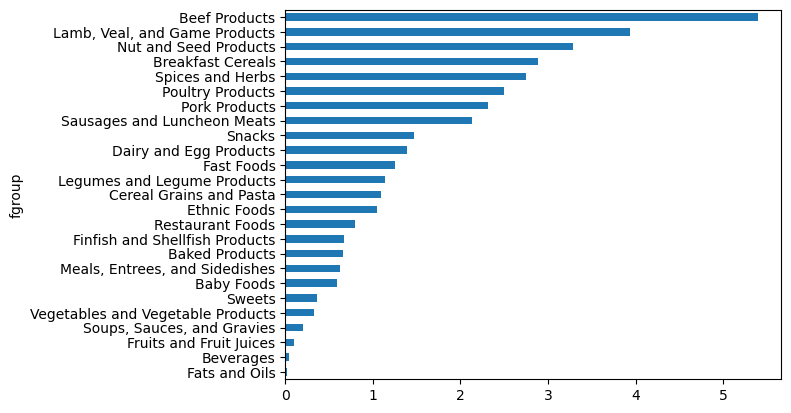

In [252]:
result['Zinc, Zn'].sort_values().plot(kind='barh')

This shows which food group gives max Zinc.

<details class="collapsible blue-box">

<summary>📘 Click to expand explanation</summary>
##### 🧠 What this line does

```python
result = ndata.groupby(['nutrient', 'fgroup'])['value'].quantile(0.5)
```

This is a **grouped aggregation** that computes the **median (50th percentile)** of nutrient values.

---

# ##### 🔍 Step-by-step breakdown

### 1. `ndata.groupby(['nutrient', 'fgroup'])`

You are grouping your data by:

* `nutrient` → e.g. Protein, Fat, Carbs
* `fgroup` → e.g. Dairy, Vegetables, Meat

👉 So each group represents:

> “All values of a specific nutrient within a specific food group”

---

### 2. `['value']`

You are selecting the **numeric column**:

* nutrient quantity (e.g. grams, mg)

---

### 3. `.quantile(0.5)`

This computes the **50th percentile** = **median**

👉 Why median?

* Robust to outliers
* Better than mean for skewed nutrition data

---

# ##### 📊 What the output looks like

The result is a **MultiIndex Series**:

```
nutrient        fgroup
Protein         Dairy and Egg Products     23.5
Protein         Vegetables                 2.1
Fat             Dairy and Egg Products     18.0
...
```

---

# ##### 🧾 Interpretation

👉 Example:

```
Protein | Dairy → 23.5
```

Means:

> Median protein content of dairy foods = 23.5g

---

# ##### ⚡ Equivalent Plain-English Meaning

> “For each nutrient and each food group, compute the median value of that nutrient across all foods in that group.”

---

# ##### 🔥 Why this is powerful

You just created a **nutrition profile by food category**:

* Compare nutrients across groups
* Identify high-protein groups
* Detect skew/outliers

---

# ##### 💡 Optional: Convert to Table Format

```python
result = result.unstack()
```

👉 Gives:

| nutrient | Dairy | Vegetables | Meat |
| -------- | ----- | ---------- | ---- |

---

# ##### 🧠 Senior Insight

This pattern is very common in:

* **EDA (Exploratory Data Analysis)**
* **Feature engineering**
* **Data warehouse aggregations**

You're essentially building:

> **grouped statistical summaries**

---



With a little cleverness, you can find which food is most dense in each nutrient:

In [255]:
by_nutrient = ndata.groupby(['nutgroup', 'nutrient'])

In [256]:
get_maximum = lambda x: x.loc[x.value.idxmax()]

In [257]:
get_minimum = lambda x: x.loc[x.value.idxmin()]

In [260]:
max_foods = by_nutrient.apply(get_maximum, include_groups=False)[['value', 'food']]

In [262]:
max_foods.food = max_foods.food.str[:50]

In [263]:
max_foods

value  \
nutgroup                          nutrient                                 
Baby Foods                        Alanine                          0.911   
                                  Alcohol, ethyl                   0.000   
                                  Arginine                         1.022   
                                  Ash                              6.640   
                                  Aspartic acid                    1.442   
...                                                                  ...   
Vegetables and Vegetable Products Vitamin E (alpha-tocopherol)    12.250   
                                  Vitamin E, added                 0.000   
                                  Vitamin K (phylloquinone)     1640.000   
                                  Water                           97.920   
                                  Zinc, Zn                         7.660   

                                                                                                          food  
nutgroup                          nutrient                                                                      
Baby Foods                        Alanine                                          Babyfood, meat, ham, junior  
                                  Alcohol, ethyl                                 Babyfood, meat, ham, strained  
                                  Arginine                                         Babyfood, meat, ham, junior  
                                  Ash                           Baby food, fortified cereal bar, fruit filling  
                                  Aspartic acid                                    Babyfood, meat, ham, junior  
...                                                                                                        ...  
Vegetables and Vegetable Products Vitamin E (alpha-tocopherol)                                   Tomato powder  
                                  Vitamin E, added                                Alfalfa seeds, sprouted, raw  
                                  Vitamin K (phylloquinone)                                       Parsley, raw  
                                  Water                                                      Butterbur, canned  
                                  Zinc, Zn                                          Mushrooms, shiitake, dried  

[2246 rows x 2 columns]

In [267]:
max_foods.index.get_level_values('nutrient').unique()

Index(['Alanine', 'Alcohol, ethyl', 'Arginine', 'Ash', 'Aspartic acid',
       'Beta-sitosterol', 'Betaine', 'Caffeine', 'Calcium, Ca', 'Campesterol',
       'Carbohydrate, by difference', 'Carotene, alpha', 'Carotene, beta',
       'Cholesterol', 'Choline, total', 'Copper, Cu', 'Cryptoxanthin, beta',
       'Cystine', 'Dihydrophylloquinone', 'Energy',
       'Fatty acids, total monounsaturated',
       'Fatty acids, total polyunsaturated', 'Fatty acids, total saturated',
       'Fatty acids, total trans', 'Fiber, total dietary', 'Fluoride, F',
       'Folate, DFE', 'Folate, food', 'Folate, total', 'Folic acid',
       'Fructose', 'Galactose', 'Glucose (dextrose)', 'Glutamic acid',
       'Glycine', 'Histidine', 'Hydroxyproline', 'Iron, Fe', 'Isoleucine',
       'Lactose', 'Leucine', 'Lutein + zeaxanthin', 'Lycopene', 'Lysine',
       'Magnesium, Mg', 'Maltose', 'Manganese, Mn', 'Menaquinone-4',
       'Methionine', 'Niacin', 'Pantothenic acid', 'Phenylalanine',
       'Phosphorus, P',

In [268]:
max_foods.index.get_level_values('nutgroup').unique()

Index(['Baby Foods', 'Baked Products', 'Beef Products', 'Beverages',
       'Breakfast Cereals', 'Cereal Grains and Pasta',
       'Dairy and Egg Products', 'Ethnic Foods', 'Fast Foods', 'Fats and Oils',
       'Finfish and Shellfish Products', 'Fruits and Fruit Juices',
       'Lamb, Veal, and Game Products', 'Legumes and Legume Products',
       'Meals, Entrees, and Sidedishes', 'Nut and Seed Products',
       'Pork Products', 'Poultry Products', 'Restaurant Foods',
       'Sausages and Luncheon Meats', 'Snacks', 'Soups, Sauces, and Gravies',
       'Spices and Herbs', 'Sweets', 'Vegetables and Vegetable Products'],
      dtype='object', name='nutgroup')

In [271]:
ndata [ndata.food=='Soy protein isolate'].nutrient.unique()

array(['Protein', 'Total lipid (fat)', 'Carbohydrate, by difference',
       'Ash', 'Energy', 'Alcohol, ethyl', 'Water', 'Caffeine',
       'Theobromine', 'Sugars, total', 'Fiber, total dietary',
       'Calcium, Ca', 'Iron, Fe', 'Magnesium, Mg', 'Phosphorus, P',
       'Potassium, K', 'Sodium, Na', 'Zinc, Zn', 'Copper, Cu',
       'Manganese, Mn', 'Selenium, Se', 'Vitamin A, IU', 'Retinol',
       'Vitamin A, RAE', 'Carotene, beta', 'Carotene, alpha',
       'Vitamin E (alpha-tocopherol)', 'Vitamin D', 'Vitamin D (D2 + D3)',
       'Cryptoxanthin, beta', 'Lycopene', 'Lutein + zeaxanthin',
       'Vitamin C, total ascorbic acid', 'Thiamin', 'Riboflavin',
       'Niacin', 'Pantothenic acid', 'Vitamin B-6', 'Folate, total',
       'Vitamin B-12', 'Choline, total', 'Vitamin K (phylloquinone)',
       'Folic acid', 'Folate, food', 'Folate, DFE', 'Vitamin E, added',
       'Vitamin B-12, added', 'Cholesterol',
       'Fatty acids, total saturated',
       'Fatty acids, total monounsaturated

## 14.5 2012 Federal Election Commission Database

The US Federal Election Commission publishes data on contributions to political
campaigns. This includes contributor names, occupation and employer, address, and
contribution amount. An interesting dataset is from the 2012 US presidential election.
A version of the dataset I downloaded in June 2012 is a 150 megabyte CSV file
P00000001-ALL.csv (see the book’s data repository), which can be loaded with `pan`

In [273]:
fec = pd.read_csv('data/election/P00000001-ALL.csv')

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\4021451084.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  fec = pd.read_csv('data/election/P00000001-ALL.csv')


In [274]:
fec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001731 entries, 0 to 1001730
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   cmte_id            1001731 non-null  object 
 1   cand_id            1001731 non-null  object 
 2   cand_nm            1001731 non-null  object 
 3   contbr_nm          1001731 non-null  object 
 4   contbr_city        1001712 non-null  object 
 5   contbr_st          1001727 non-null  object 
 6   contbr_zip         1001620 non-null  object 
 7   contbr_employer    988002 non-null   object 
 8   contbr_occupation  993301 non-null   object 
 9   contb_receipt_amt  1001731 non-null  float64
 10  contb_receipt_dt   1001731 non-null  object 
 11  receipt_desc       14166 non-null    object 
 12  memo_cd            92482 non-null    object 
 13  memo_text          97770 non-null    object 
 14  form_tp            1001731 non-null  object 
 15  file_num           1001731 non-n

A sample record in the DataFrame looks like this:

In [275]:
fec.iloc[123456]

cmte_id             C00431445
cand_id             P80003338
cand_nm         Obama, Barack
contbr_nm         ELLMAN, IRA
contbr_city             TEMPE
                    ...      
receipt_desc              NaN
memo_cd                   NaN
memo_text                 NaN
form_tp                 SA17A
file_num               772372
Name: 123456, Length: 16, dtype: object

You may think of some ways to start slicing and dicing this data to extract informative
statistics about donors and patterns in the campaign contributions. I’ll show you
a number of different analyses that apply techniques in this book.

You can see that there are no political party affiliations in the data, so this would be
useful to add. You can get a list of all the unique political candidates using unique:

In [278]:
unique_cands = fec.cand_nm.unique()

In [279]:
unique_cands

array(['Bachmann, Michelle', 'Romney, Mitt', 'Obama, Barack',
       "Roemer, Charles E. 'Buddy' III", 'Pawlenty, Timothy',
       'Johnson, Gary Earl', 'Paul, Ron', 'Santorum, Rick',
       'Cain, Herman', 'Gingrich, Newt', 'McCotter, Thaddeus G',
       'Huntsman, Jon', 'Perry, Rick'], dtype=object)

One way to indicate party affiliation is using a dict:

In [280]:
parties = {'Bachmann, Michelle': 'Republican',
'Cain, Herman': 'Republican',
'Gingrich, Newt': 'Republican',
'Huntsman, Jon': 'Republican',
'Johnson, Gary Earl': 'Republican',
'McCotter, Thaddeus G': 'Republican',
'Obama, Barack': 'Democrat',
'Paul, Ron': 'Republican',
'Pawlenty, Timothy': 'Republican',
'Perry, Rick': 'Republican',
"Roemer, Charles E. 'Buddy' III": 'Republican',
'Romney, Mitt': 'Republican',
'Santorum, Rick': 'Republican'}


(1 This makes the simplifying assumption that Gary Johnson is a Republican even though he later became the
Libertarian party candidate.)

Now, using this mapping and the `map` method on Series objects, you can compute an
array of political parties from the candidate names:

In [282]:
fec.cand_nm[123456:123461]

123456    Obama, Barack
123457    Obama, Barack
123458    Obama, Barack
123459    Obama, Barack
123460    Obama, Barack
Name: cand_nm, dtype: object

In [283]:
fec.cand_nm[123456:123461].map(parties)

123456    Democrat
123457    Democrat
123458    Democrat
123459    Democrat
123460    Democrat
Name: cand_nm, dtype: object

Add it as a columne :

In [286]:
fec['party'] = fec.cand_nm.map(parties)

In [287]:
fec['party'].value_counts()

party
Democrat      593746
Republican    407985
Name: count, dtype: int64

A couple of data preparation points. First, this data includes both contributions and
refunds (negative contribution amount):

In [289]:
(fec.contb_receipt_amt > 0).value_counts()

contb_receipt_amt
True     991475
False     10256
Name: count, dtype: int64

To simplify the analysis, I’ll restrict the dataset to positive contributions:

In [291]:
fec = fec[fec.contb_receipt_amt > 0]

Since Barack Obama and Mitt Romney were the main two candidates, I’ll also prepare
a subset that just has contributions to their campaigns:

In [292]:
fec_mrbo = fec[fec.cand_nm.isin(['Obama, Barack', 'Romney, Mitt'])]

### Donation Statistics by Occupation and Employer

Donations by occupation is another oft-studied statistic. For example, lawyers (attorneys)
tend to donate more money to Democrats, while business executives tend to
donate more to Republicans. You have no reason to believe me; you can see for yourself
in the data. First, the total number of donations by occupation is easy:

In [295]:
fec.contbr_occupation.value_counts()[:10]

contbr_occupation
RETIRED                                   233990
INFORMATION REQUESTED                      35107
ATTORNEY                                   34286
HOMEMAKER                                  29931
PHYSICIAN                                  23432
INFORMATION REQUESTED PER BEST EFFORTS     21138
ENGINEER                                   14334
TEACHER                                    13990
CONSULTANT                                 13273
PROFESSOR                                  12555
Name: count, dtype: int64

You will notice by looking at the occupations that many refer to the same basic job
type, or there are several variants of the same thing. The following code snippet illustrates
a technique for cleaning up a few of them by mapping from one occupation to
another; note the “trick” of using `dict.get` to allow occupations with no mapping to
“pass through”:

In [296]:
occ_mapping = {
'INFORMATION REQUESTED PER BEST EFFORTS' : 'NOT PROVIDED',
'INFORMATION REQUESTED' : 'NOT PROVIDED',
'INFORMATION REQUESTED (BEST EFFORTS)' : 'NOT PROVIDED',
'C.E.O.': 'CEO'
}

In [297]:
f = lambda x: occ_mapping.get(x, x)

In [298]:
fec.contbr_occupation = fec.contbr_occupation.map(f)

I’ll also do the same thing for employers:

In [299]:
emp_mapping = {
'INFORMATION REQUESTED PER BEST EFFORTS' : 'NOT PROVIDED',
'INFORMATION REQUESTED' : 'NOT PROVIDED',
'SELF' : 'SELF-EMPLOYED',
'SELF EMPLOYED' : 'SELF-EMPLOYED',
}

In [300]:
# If no mapping provided, return x
f = lambda x: emp_mapping.get(x, x)
fec.contbr_employer = fec.contbr_employer.map(f)

Now, you can use `pivot_table` to aggregate the data by party and occupation, then
filter down to the subset that donated at least $2 million overall:

In [301]:
by_occupation = fec.pivot_table('contb_receipt_amt',
                                index='contbr_occupation',
                                columns='party', aggfunc='sum')

In [302]:
over_2mm = by_occupation[by_occupation.sum(1) > 2000000]

In [303]:
over_2mm

party,Democrat,Republican
contbr_occupation,,
ATTORNEY,11141982.97,7477194.43
CEO,2074974.79,4211040.52
CONSULTANT,2459912.71,2544725.45
ENGINEER,951525.55,1818373.70
EXECUTIVE,1355161.05,4138850.09
...,...,...
PRESIDENT,1878509.95,4720923.76
PROFESSOR,2165071.08,296702.73
REAL ESTATE,528902.09,1625902.25


It can be easier to look at this data graphically as a bar plot ('barh' means horizontal
bar plot)

<Axes: ylabel='contbr_occupation'>

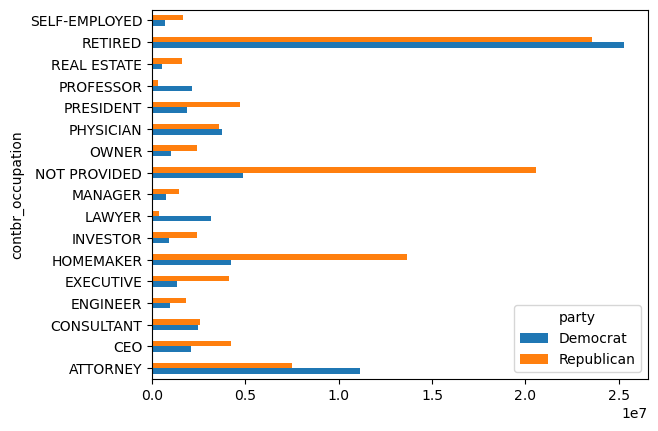

In [305]:
over_2mm.plot(kind='barh')

You might be interested in the top donor occupations or top companies that donated
to Obama and Romney. To do this, you can group by candidate name and use a variant
of the `top` method from earlier in the chapter:



In [306]:
def get_top_amounts(group, key, n=5):
    totals = group.groupby(key)['contb_receipt_amt'].sum()
    return totals.nlargest(n)

Then aggregate by occupation and employer:

In [308]:
grouped = fec_mrbo.groupby('cand_nm')

In [310]:
grouped

In [309]:
grouped.apply(get_top_amounts, 'contbr_occupation', n=7)

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\3062593903.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(get_top_amounts, 'contbr_occupation', n=7)


cand_nm        contbr_occupation    
Obama, Barack  RETIRED                  25305116.38
               ATTORNEY                 11141982.97
               INFORMATION REQUESTED     4866973.96
               HOMEMAKER                 4248875.80
               PHYSICIAN                 3735124.94
                                           ...     
Romney, Mitt   HOMEMAKER                 8147446.22
               ATTORNEY                  5364718.82
               PRESIDENT                 2491244.89
               EXECUTIVE                 2300947.03
               C.E.O.                    1968386.11
Name: contb_receipt_amt, Length: 14, dtype: float64

In [311]:
grouped.apply(get_top_amounts, 'contbr_employer', n=10)

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_16568\1241302789.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(get_top_amounts, 'contbr_employer', n=10)


cand_nm        contbr_employer      
Obama, Barack  RETIRED                  22694358.85
               SELF-EMPLOYED            17080985.96
               NOT EMPLOYED              8586308.70
               INFORMATION REQUESTED     5053480.37
               HOMEMAKER                 2605408.54
                                           ...     
Romney, Mitt   CREDIT SUISSE              281150.00
               MORGAN STANLEY             267266.00
               GOLDMAN SACH & CO.         238250.00
               BARCLAYS CAPITAL           162750.00
               H.I.G. CAPITAL             139500.00
Name: contb_receipt_amt, Length: 20, dtype: float64

#### Bucketing Donation Amounts

A useful way to analyze this data is to use the `cut` function to discretize the contributor
amounts into buckets by contribution size:



In [314]:
bins = np.array([0, 1, 10, 100, 1000, 10000,100000, 1000000, 10000000])

In [315]:
labels = pd.cut(fec_mrbo.contb_receipt_amt, bins)

In [316]:
labels

411         (10, 100]
412       (100, 1000]
413       (100, 1000]
414         (10, 100]
415         (10, 100]
             ...     
701381      (10, 100]
701382    (100, 1000]
701383        (1, 10]
701384      (10, 100]
701385    (100, 1000]
Name: contb_receipt_amt, Length: 694282, dtype: category
Categories (8, interval[int64, right]): [(0, 1] < (1, 10] < (10, 100] < (100, 1000] < (1000, 10000] < (10000, 100000] < (100000, 1000000] < (1000000, 10000000]]

We can then group the data for Obama and Romney by name and bin label to get a
histogram by donation size:

In [318]:
grouped = fec_mrbo.groupby(['cand_nm', labels], observed=False)

In [320]:
grouped.size()

cand_nm        contb_receipt_amt  
Obama, Barack  (0, 1]                    493
               (1, 10]                 40070
               (10, 100]              372280
               (100, 1000]            153991
               (1000, 10000]           22284
                                       ...  
Romney, Mitt   (100, 1000]             43357
               (1000, 10000]           26186
               (10000, 100000]             1
               (100000, 1000000]           0
               (1000000, 10000000]         0
Length: 16, dtype: int64

In [322]:
grouped.size().unstack(0)

cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(0, 1]",493,77
"(1, 10]",40070,3681
"(10, 100]",372280,31853
"(100, 1000]",153991,43357
"(1000, 10000]",22284,26186
"(10000, 100000]",2,1
"(100000, 1000000]",3,0
"(1000000, 10000000]",4,0


This data shows that Obama received a significantly larger number of small donations
than Romney. You can also sum the contribution amounts and normalize within
buckets to visualize percentage of total donations of each size by candidate.

In [324]:
bucket_sums = grouped.contb_receipt_amt.sum().unstack(0)

In [325]:
bucket_sums 

cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(0, 1]",318.24,77.00
"(1, 10]",337267.62,29819.66
"(10, 100]",20288981.41,1987783.76
"(100, 1000]",54798531.46,22363381.69
"(1000, 10000]",51753705.67,63942145.42
"(10000, 100000]",59100.00,12700.00
"(100000, 1000000]",1490683.08,0.00
"(1000000, 10000000]",7148839.76,0.00


In [326]:
normed_sums = bucket_sums.div(bucket_sums.sum(axis=1), axis=0)

In [329]:
normed_sums

cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(0, 1]",0.805182,0.194818
"(1, 10]",0.918767,0.081233
"(10, 100]",0.910769,0.089231
"(100, 1000]",0.710176,0.289824
"(1000, 10000]",0.447326,0.552674
"(10000, 100000]",0.823120,0.176880
"(100000, 1000000]",1.000000,0.000000
"(1000000, 10000000]",1.000000,0.000000


<Axes: ylabel='contb_receipt_amt'>

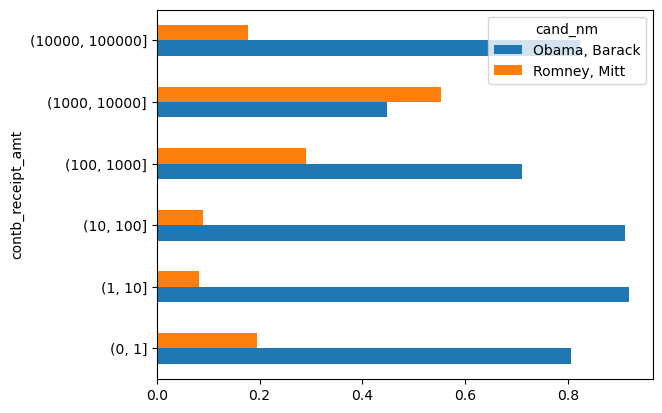

In [330]:
normed_sums[:-2].plot(kind='barh')

I excluded the two largest bins as these are not donations by individuals.
This analysis can be refined and improved in many ways. For example, you could
aggregate donations by donor name and zip code to adjust for donors who gave many
small amounts versus one or more large donations. I encourage you to download and
explore the dataset yourself.

### Donation Statistics by State

Aggregating the data by candidate and state is a routine affair:

In [333]:
grouped = fec_mrbo.groupby(['cand_nm', 'contbr_st'])

In [334]:
totals = grouped.contb_receipt_amt.sum().unstack(0).fillna(0)

In [335]:
totals = totals[totals.sum(1) > 100000]

In [336]:
totals[:10]

cand_nm,"Obama, Barack","Romney, Mitt"
contbr_st,,
AK,281840.15,86204.24
AL,543123.48,527303.51
AR,359247.28,105556.00
AZ,1506476.98,1888436.23
CA,23824984.24,11237636.60
CO,2132429.49,1506714.12
CT,2068291.26,3499475.45
DC,4373538.80,1025137.50
DE,336669.14,82712.00


If you divide each row by the total contribution amount, you get the relative percentage
of total donations by state for each candidate:

In [337]:
percent = totals.div(totals.sum(1), axis=0)

In [338]:
percent[:10]

cand_nm,"Obama, Barack","Romney, Mitt"
contbr_st,,
AK,0.765778,0.234222
AL,0.507390,0.492610
AR,0.772902,0.227098
AZ,0.443745,0.556255
CA,0.679498,0.320502
CO,0.585970,0.414030
CT,0.371476,0.628524
DC,0.810113,0.189887
DE,0.802776,0.197224


## 14.6 Conclusion

We’ve reached the end of the book’s main chapters. I have included some additional
content you may find useful in the appendixes.
In the five years since the first edition of this book was published, Python has become
a popular and widespread language for data analysis. The programming skills you
have developed here will stay relevant for a long time into the future. I hope the programming
tools and libraries we’ve explored serve you well in your work.`m